<a href="https://colab.research.google.com/github/milkpotato1000/bigCon_hom/blob/jin2/bigcon_jin3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 분석 개요

분석 목표 등 요약
- 주제 : 미래를 예측하는 데이터 챌린지 -- 우리 동네 가맹점, 위기 신호를 미리 잡아라!
(영세/중소 요식 가맹업 경영 위기 조기 경보 시스템 제안)
- 가맹점이 갑자기 어려워지는 순간(매출 급락, 폐업 위험 등)을 미리 감지할수 있는 'AI 조기 경보 시스템 제안'
- 데이터에서 어떤 신호가 위기를 미리 알려주는지 직접 찾아내고, 이 결과를 소상공인이 활용할 수 있는 아이디어도 제안



"이번 빅콘테스트에 제공된 데이터 모수는 '25 하반기 기준 영세, 중소 가맹점 기준입니다."
데이터 전처리 과정 중 '24년 매출 기준 국세청 데이터를 '25 하반기 카드사 가맹점 정보와 매칭 과정에서 폐업된 가맹점은 제외되어 산출됩니다.
"따라서 데이터 분석은 주어진 '23.1~'24.12 데이터를 기반으로 '25.7월 이후 가맹점이 어려워지는 순간(폐업, 매출 급락) 을 감지할 수 있는 'AI 조기 경보 시스템'을 제안해주시면 됩니다."
```


데이터 정의서 등 참고 문서
- https://docs.google.com/spreadsheets/d/1Xepbio9MctRbELhnMcaqg9ln--wRQMYTL5g0wgS02wc/edit?gid=1092014041#gid=1092014041

# 데이터 로드

In [ ]:
import numpy as np
import pandas as pd
import os

# 코랩 구글 드라이브용 경로
try:
    df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set1_f.csv', encoding='cp949')
    df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set2_f.csv', encoding='cp949')
    df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set3_f.csv', encoding='cp949')
except UnicodeDecodeError:
    print("Could not decode using cp949, trying utf-8")
    df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set1_f.csv', encoding='utf-8')
    df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set2_f.csv', encoding='utf-8')
    df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set3_f.csv', encoding='utf-8')


# 로컬용 경로

# 캐글용 경로
# train_df = pd.read_csv('/kaggle/input/modu-ds-5-house-prices-prediction/train.csv')
# test_df = pd.read_csv('/kaggle/input/modu-ds-5-house-prices-prediction/test.csv')

# EDA

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ENCODED_MCT         4185 non-null   object 
 1   MCT_BSE_AR          4185 non-null   object 
 2   MCT_NM              4185 non-null   object 
 3   MCT_BRD_NUM         542 non-null    object 
 4   MCT_SIGUNGU_NM      4185 non-null   object 
 5   HPSN_MCT_ZCD_NM     4185 non-null   object 
 6   HPSN_MCT_BZN_CD_NM  3138 non-null   object 
 7   ARE_D               4185 non-null   int64  
 8   MCT_ME_D            127 non-null    float64
dtypes: float64(1), int64(1), object(7)
memory usage: 294.4+ KB


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ENCODED_MCT             86590 non-null  object 
 1   TA_YM                   86590 non-null  int64  
 2   MCT_OPE_MS_CN           86590 non-null  object 
 3   RC_M1_SAA               86590 non-null  object 
 4   RC_M1_TO_UE_CT          86590 non-null  object 
 5   RC_M1_UE_CUS_CN         86590 non-null  object 
 6   RC_M1_AV_NP_AT          86590 non-null  object 
 7   APV_CE_RAT              79958 non-null  object 
 8   DLV_SAA_RAT             86590 non-null  float64
 9   M1_SME_RY_SAA_RAT       86590 non-null  float64
 10  M1_SME_RY_CNT_RAT       86590 non-null  float64
 11  M12_SME_RY_SAA_PCE_RT   86590 non-null  float64
 12  M12_SME_BZN_SAA_PCE_RT  86590 non-null  float64
 13  M12_SME_RY_ME_MCT_RAT   86590 non-null  float64
 14  M12_SME_BZN_ME_MCT_RAT  86590 non-null

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86590 non-null  object 
 1   TA_YM                     86590 non-null  int64  
 2   M12_MAL_1020_RAT          86590 non-null  float64
 3   M12_MAL_30_RAT            86590 non-null  float64
 4   M12_MAL_40_RAT            86590 non-null  float64
 5   M12_MAL_50_RAT            86590 non-null  float64
 6   M12_MAL_60_RAT            86590 non-null  float64
 7   M12_FME_1020_RAT          86590 non-null  float64
 8   M12_FME_30_RAT            86590 non-null  float64
 9   M12_FME_40_RAT            86590 non-null  float64
 10  M12_FME_50_RAT            86590 non-null  float64
 11  M12_FME_60_RAT            86590 non-null  float64
 12  MCT_UE_CLN_REU_RAT        86590 non-null  float64
 13  MCT_UE_CLN_NEW_RAT        86590 non-null  float64
 14  RC_M1_

In [ ]:
df1.head(5)

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN


In [ ]:
df2.head(5)

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


In [ ]:
df3.head(5)

,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


In [ ]:
df1['MCT_BSE_AR'].value_counts()

,count
MCT_BSE_AR,
서울특별시 성동구 왕십리로 410,73
서울특별시 성동구 마장로 137,38
서울특별시 성동구 왕십리광장로 17,31
서울 성동구 마장동,21
서울특별시 성동구 무학로6길 50,18
...,...
서울특별시 성동구 장터길 45,1
서울특별시 성동구 장터길 47,1
서울특별시 성동구 행당로 43,1


In [ ]:
df1['HPSN_MCT_BZN_CD_NM'].value_counts()

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


In [ ]:
df2['MCT_OPE_MS_CN'].value_counts()

,count
MCT_OPE_MS_CN,
3_25-50%,21812
4_50-75%,21567
5_75-90%,13454
2_10-25%,13119
1_10%이하,8691
6_90%초과(하위 10% 이하),7947


### df1 형별

In [ ]:
object_columns = df1.select_dtypes(include='object').columns.tolist()
numeric_columns = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Object Columns:", object_columns)
print("Numeric Columns:", numeric_columns)

Object Columns: ['ENCODED_MCT', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'MCT_SIGUNGU_NM', 'HPSN_MCT_ZCD_NM', 'HPSN_MCT_BZN_CD_NM']
Numeric Columns: ['ARE_D', 'MCT_ME_D']


/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 50773 (\N{HANGUL SYLLABLE WANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

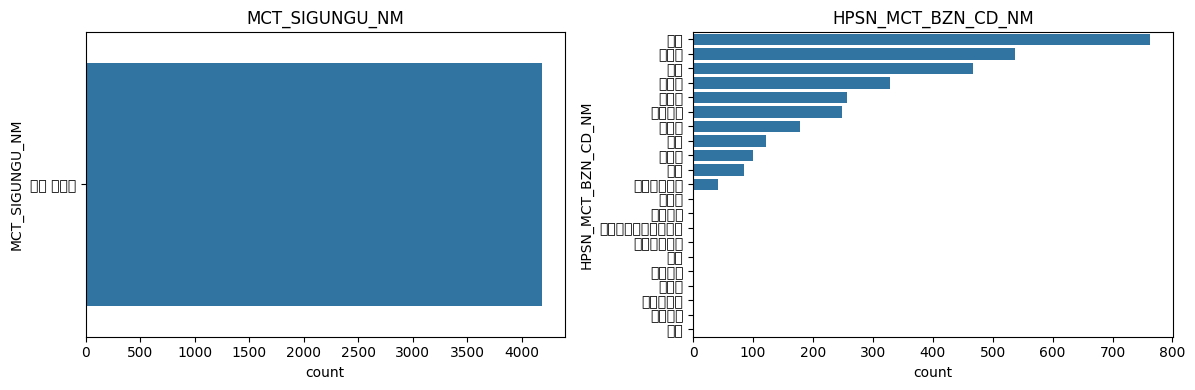

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out columns with too many unique values for plotting
object_columns_to_plot = [col for col in object_columns if df1[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df1, order=df1[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

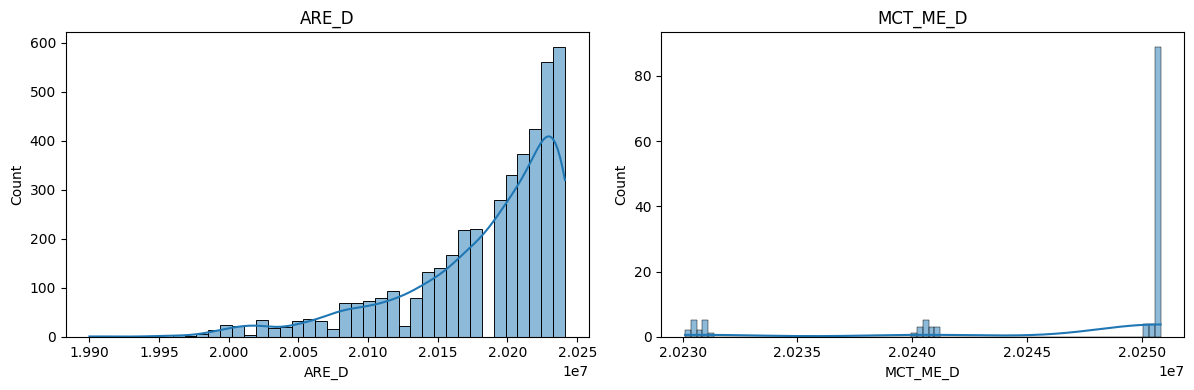

In [ ]:
n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(numeric_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    if df1[col].nunique() > 50:  # Use histogram for columns with many unique values
        sns.histplot(data=df1, x=col, kde=True)
    else:  # Use countplot or barplot for columns with few unique values
        sns.countplot(data=df1, y=col, order=df1[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

### df2 형별

In [ ]:
df2_object_columns = df2.select_dtypes(include='object').columns.tolist()
df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("df2 Object Columns:", df2_object_columns)
print("df2 Numeric Columns:", df2_numeric_columns)

df2 Object Columns: ['ENCODED_MCT', 'MCT_OPE_MS_CN', 'RC_M1_SAA', 'RC_M1_TO_UE_CT', 'RC_M1_UE_CUS_CN', 'RC_M1_AV_NP_AT', 'APV_CE_RAT']
df2 Numeric Columns: ['TA_YM', 'DLV_SAA_RAT', 'M1_SME_RY_SAA_RAT', 'M1_SME_RY_CNT_RAT', 'M12_SME_RY_SAA_PCE_RT', 'M12_SME_BZN_SAA_PCE_RT', 'M12_SME_RY_ME_MCT_RAT', 'M12_SME_BZN_ME_MCT_RAT']


Using font: ['NanumGothic']


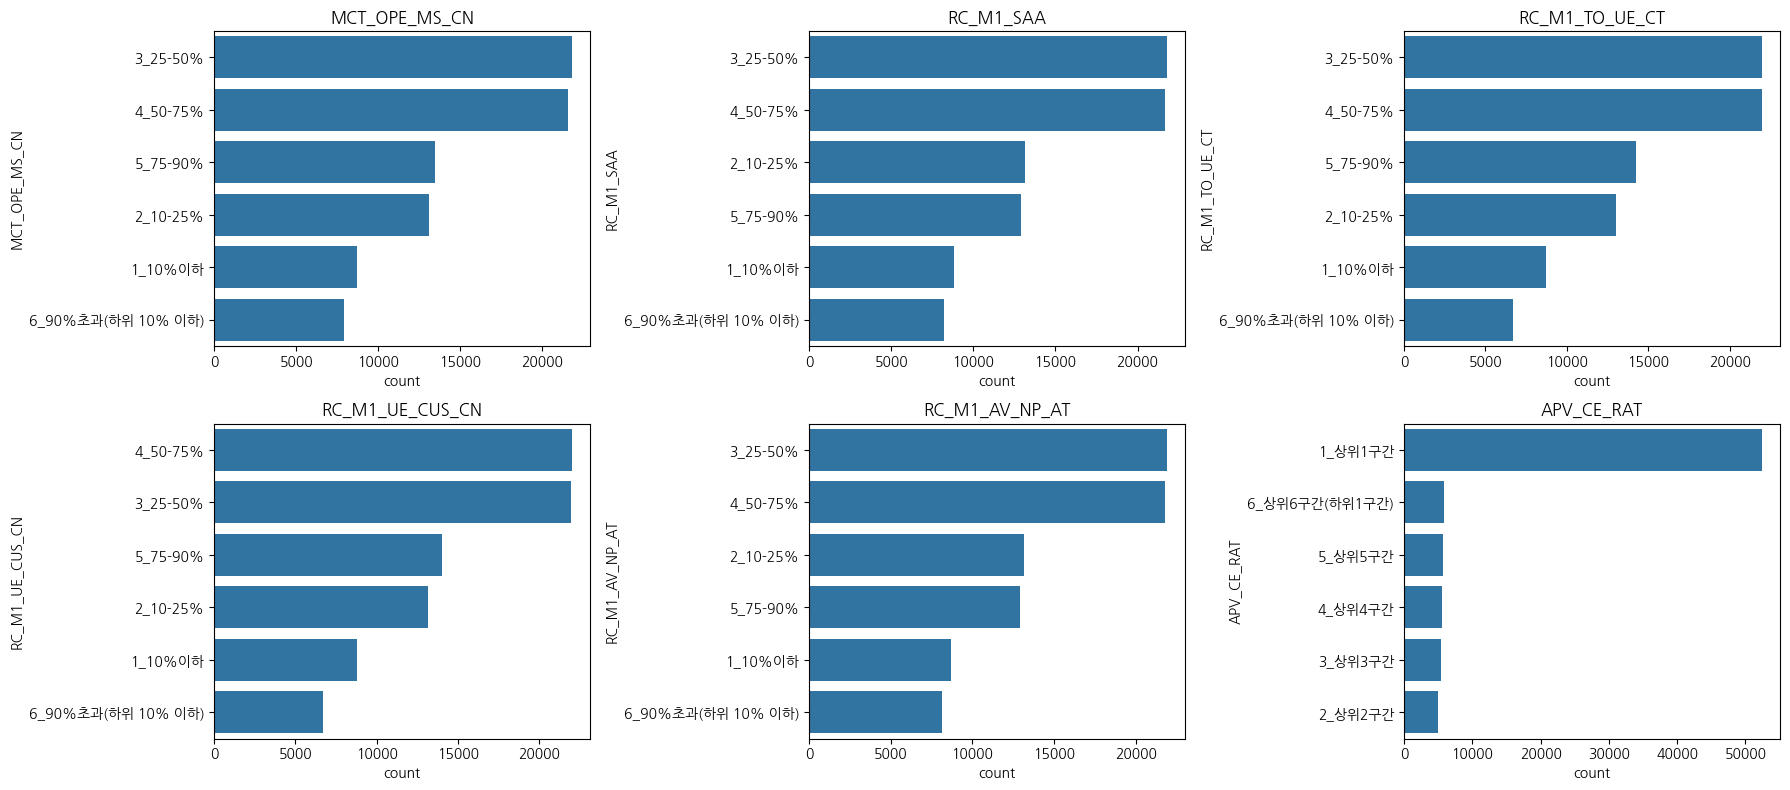

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# Find the Nanum font file
nanum_font_path = None
for font_path in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'NanumGothic' in font_path:
        nanum_font_path = font_path
        break

if nanum_font_path:
    # Add the font to matplotlib's font manager
    fm.fontManager.addfont(nanum_font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Using font: {plt.rcParams['font.family']}")
else:
    print("NanumGothic font not found.")
    # Fallback to a default font if NanumGothic is not found
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = True


# Filter out columns with too many unique values for plotting
df2_object_columns_to_plot = [col for col in df2_object_columns if df2[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(df2_object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(df2_object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df2, order=df2[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.font_manager as fm

# # Find available Korean fonts and set font
# font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
# korean_font_list = [f for f in font_list if 'Nanum' in f or 'Malgun' in f]

# if len(korean_font_list) > 0:
#     # Use the first found Korean font
#     plt.rcParams['font.family'] = fm.FontProperties(fname=korean_font_list[0]).get_name()
#     plt.rcParams['axes.unicode_minus'] = False
#     print(f"Using font: {plt.rcParams['font.family']}")
# else:
#     print("No Korean fonts found on the system.")
#     # Fallback to a default font if no Korean font is found
#     plt.rcParams['font.family'] = 'DejaVu Sans'
#     plt.rcParams['axes.unicode_minus'] = True

# # Identify numeric columns in df2 (assuming df2_numeric_columns is already defined)
# df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

# n_cols = 3
# n_rows = (len(df2_numeric_columns) + n_cols - 1) // n_cols

# plt.figure(figsize=(n_cols * 6, n_rows * 4))

# for i, col in enumerate(df2_numeric_columns):
#     plt.subplot(n_rows, n_cols, i + 1)
#     if df2[col].nunique() > 50:  # Use histogram for columns with many unique values
#         sns.histplot(data=df2, x=col, kde=True)
#     else:  # Use countplot or barplot for columns with few unique values
#         sns.countplot(data=df2, y=col, order=df2[col].value_counts().index)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

### df3 형별

In [ ]:
df3_object_columns = df3.select_dtypes(include='object').columns.tolist()
df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("df3 Object Columns:", df3_object_columns)
print("df3 Numeric Columns:", df3_numeric_columns)

df3 Object Columns: ['ENCODED_MCT']
df3 Numeric Columns: ['TA_YM', 'M12_MAL_1020_RAT', 'M12_MAL_30_RAT', 'M12_MAL_40_RAT', 'M12_MAL_50_RAT', 'M12_MAL_60_RAT', 'M12_FME_1020_RAT', 'M12_FME_30_RAT', 'M12_FME_40_RAT', 'M12_FME_50_RAT', 'M12_FME_60_RAT', 'MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT', 'RC_M1_SHC_RSD_UE_CLN_RAT', 'RC_M1_SHC_WP_UE_CLN_RAT', 'RC_M1_SHC_FLP_UE_CLN_RAT']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out columns with too many unique values for plotting
df3_object_columns_to_plot = [col for col in df3_object_columns if df3[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(df3_object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(df3_object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df3, order=df3[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

<Figure size 1800x0 with 0 Axes>

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Identify numeric columns in df3 (assuming df3_numeric_columns is already defined)
# df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()


# n_cols = 3
# n_rows = (len(df3_numeric_columns) + n_cols - 1) // n_cols

# plt.figure(figsize=(n_cols * 6, n_rows * 4))

# for i, col in enumerate(df3_numeric_columns):
#     plt.subplot(n_rows, n_cols, i + 1)
#     if df3[col].nunique() > 50:  # Use histogram for columns with many unique values
#         sns.histplot(data=df3, x=col, kde=True)
#     else:  # Use countplot or barplot for columns with few unique values
#         sns.countplot(data=df3, y=col, order=df3[col].value_counts().index)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

## 결측치 확인

In [ ]:
# Check for missing values in df1 and calculate the percentage
missing_df1 = df1.isnull().sum()
missing_percent_df1 = (missing_df1 / len(df1)) * 100
missing_info_df1 = pd.DataFrame({'Missing Count': missing_df1, 'Missing Percentage': missing_percent_df1})
missing_info_df1 = missing_info_df1[missing_info_df1['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Check for missing values in df2 and calculate the percentage
missing_df2 = df2.isnull().sum()
missing_percent_df2 = (missing_df2 / len(df2)) * 100
missing_info_df2 = pd.DataFrame({'Missing Count': missing_df2, 'Missing Percentage': missing_percent_df2})
missing_info_df2 = missing_info_df2[missing_info_df2['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Check for missing values in df3 and calculate the percentage
missing_df3 = df3.isnull().sum()
missing_percent_df3 = (missing_df3 / len(df3)) * 100
missing_info_df3 = pd.DataFrame({'Missing Count': missing_df3, 'Missing Percentage': missing_percent_df3})
missing_info_df3 = missing_info_df3[missing_info_df3['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing values in df1:")
display(missing_info_df1)

print("\nMissing values in df2:")
display(missing_info_df2)

print("\nMissing values in df3:")
display(missing_info_df3)

Missing values in df1:


,Missing Count,Missing Percentage
MCT_ME_D,4058,96.965352
MCT_BRD_NUM,3643,87.048984
HPSN_MCT_BZN_CD_NM,1047,25.017921



Missing values in df2:


,Missing Count,Missing Percentage
APV_CE_RAT,6632,7.659083



Missing values in df3:


,Missing Count,Missing Percentage


Using font: ['NanumMyeongjo']


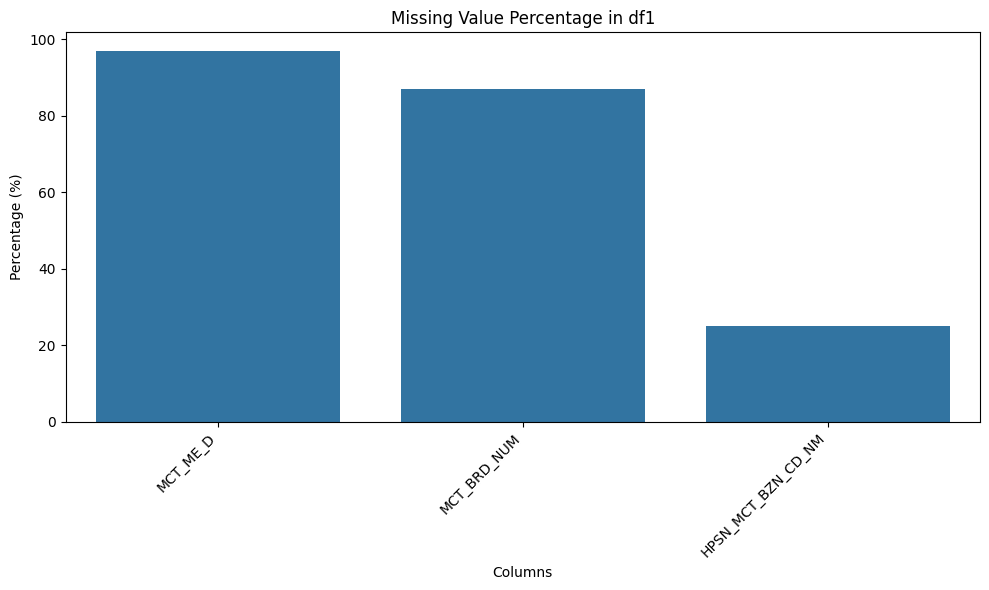

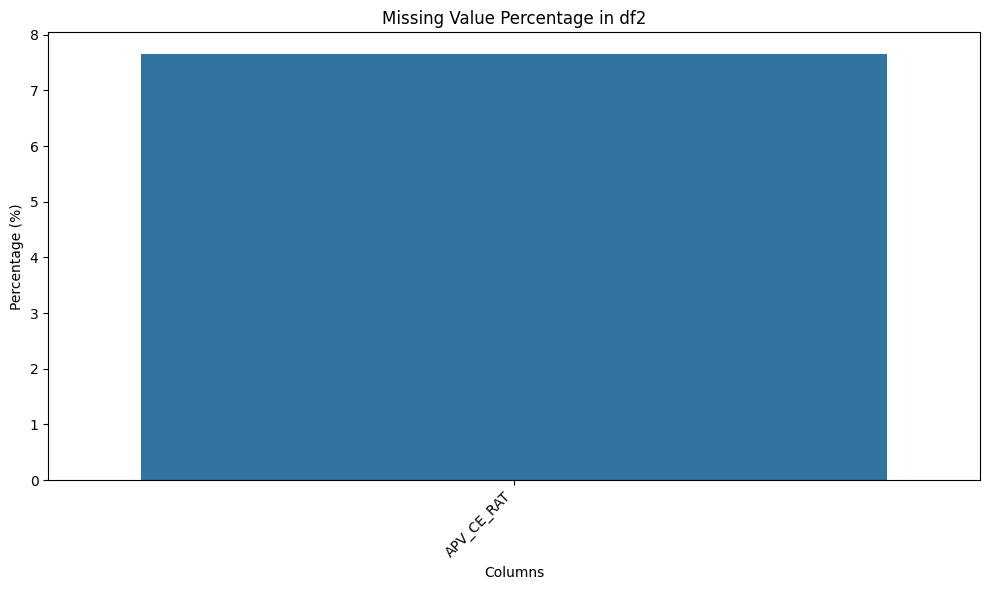

No missing values to plot for df3.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Find available Korean fonts and set font
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
korean_font_list = [f for f in font_list if 'Nanum' in f or 'Malgun' in f]

if len(korean_font_list) > 0:
    # Use the first found Korean font
    plt.rcParams['font.family'] = fm.FontProperties(fname=korean_font_list[0]).get_name()
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Using font: {plt.rcParams['font.family']}")
else:
    print("No Korean fonts found on the system.")
    # Fallback to a default font if no Korean font is found
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = True

# Plot missing values for df1
if not missing_info_df1.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df1.index, y='Missing Percentage', data=missing_info_df1)
    plt.title('Missing Value Percentage in df1')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df1.")

# Plot missing values for df2
if not missing_info_df2.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df2.index, y='Missing Percentage', data=missing_info_df2)
    plt.title('Missing Value Percentage in df2')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df2.")

# Plot missing values for df3
if not missing_info_df3.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df3.index, y='Missing Percentage', data=missing_info_df3)
    plt.title('Missing Value Percentage in df3')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df3.")

## 기초 통계량

In [ ]:
# Calculate and display basic statistics for numeric columns in df1
print("Basic statistics for numeric columns in df1:")
display(df1.describe())

# Calculate and display basic statistics for numeric columns in df2
print("\nBasic statistics for numeric columns in df2:")
display(df2.describe())

# Calculate and display basic statistics for numeric columns in df3
print("\nBasic statistics for numeric columns in df3:")
display(df3.describe())

Basic statistics for numeric columns in df1:


,ARE_D,MCT_ME_D
count,4.185000e+03,1.270000e+02
mean,2.018352e+07,2.024716e+07
std,5.743071e+04,6.859542e+03
min,1.990023e+07,2.023010e+07
25%,2.016032e+07,2.025017e+07
50%,2.020073e+07,2.025072e+07
75%,2.023033e+07,2.025080e+07
max,2.024122e+07,2.025082e+07



Basic statistics for numeric columns in df2:


,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
count,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000
mean,202360.704850,-662249.470344,134.503306,152.312380,31.184643,24.070313,16.187137,-247354.685375
std,49.948354,472955.612921,167.981671,227.070665,25.253279,22.843491,3.876532,431484.515919
min,202301.000000,-999999.900000,-70.000000,0.000000,0.100000,0.000000,0.000000,-999999.900000
25%,202307.000000,-999999.900000,25.200000,22.100000,9.900000,1.300000,14.100000,4.200000
50%,202401.000000,-999999.900000,82.500000,81.700000,23.900000,18.900000,17.000000,8.000000
75%,202407.000000,3.400000,181.700000,199.600000,48.200000,39.200000,18.700000,9.000000
max,202412.000000,111.200000,4300.900000,7059.800000,100.000000,99.600000,59.100000,13.900000



Basic statistics for numeric columns in df3:


,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
count,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000
mean,202360.704850,-23132.288511,-23130.483150,-23133.699739,-23132.727377,-23134.757761,-23132.931257,-23132.508397,-23135.875375,-23135.667261,-23136.852116,-18949.612306,-18964.829428,-84585.222446,-84605.088521,-84569.608085
std,49.948354,150361.910036,150362.187842,150361.692698,150361.842481,150361.530077,150361.811198,150361.876105,150361.357768,150361.389830,150361.207660,136439.003444,136436.887054,278322.440389,278316.399644,278327.187716
min,202301.000000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000
25%,202307.000000,3.744925,7.509725,4.889600,4.441050,1.464000,2.272000,5.232150,4.171050,4.088000,1.358550,13.820000,4.970000,10.400000,1.100000,30.300000
50%,202401.000000,9.637500,12.284000,9.258800,8.795350,4.818600,6.802500,9.657850,6.669800,6.579150,3.369250,24.030000,6.700000,28.100000,7.600000,48.000000
75%,202407.000000,15.903450,17.985750,13.299000,14.926850,12.045925,15.247550,15.748650,9.725000,10.098000,7.451300,33.750000,8.780000,50.000000,17.100000,66.300000
max,202412.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


## 이상치 확인

In [ ]:
# # Get the list of numeric columns for each dataframe
# df1_numeric_columns = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()
# df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()
# df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()

# # Function to create box plots for numeric columns, handling placeholder values
# def plot_numeric_boxplot(df, numeric_cols, df_name):
#     # Replace placeholder value with NaN for plotting purposes
#     df_cleaned = df.replace(-999999.9, np.nan)

#     n_cols = 3
#     n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

#     plt.figure(figsize=(n_cols * 6, n_rows * 4))

#     for i, col in enumerate(numeric_cols):
#         plt.subplot(n_rows, n_cols, i + 1)
#         sns.boxplot(data=df_cleaned, y=col)
#         plt.title(f'{df_name} - Box Plot of {col}')
#         plt.ylabel(col)

#     plt.tight_layout()
#     plt.show()

# # Plot box plots for numeric columns in each dataframe
# print("Box plots for df1 numeric columns:")
# plot_numeric_boxplot(df1, df1_numeric_columns, 'df1')

# print("\nBox plots for df2 numeric columns:")
# plot_numeric_boxplot(df2, df2_numeric_columns, 'df2')

# print("\nBox plots for df3 numeric columns:")
# plot_numeric_boxplot(df3, df3_numeric_columns, 'df3')

## 상관 관계 분석

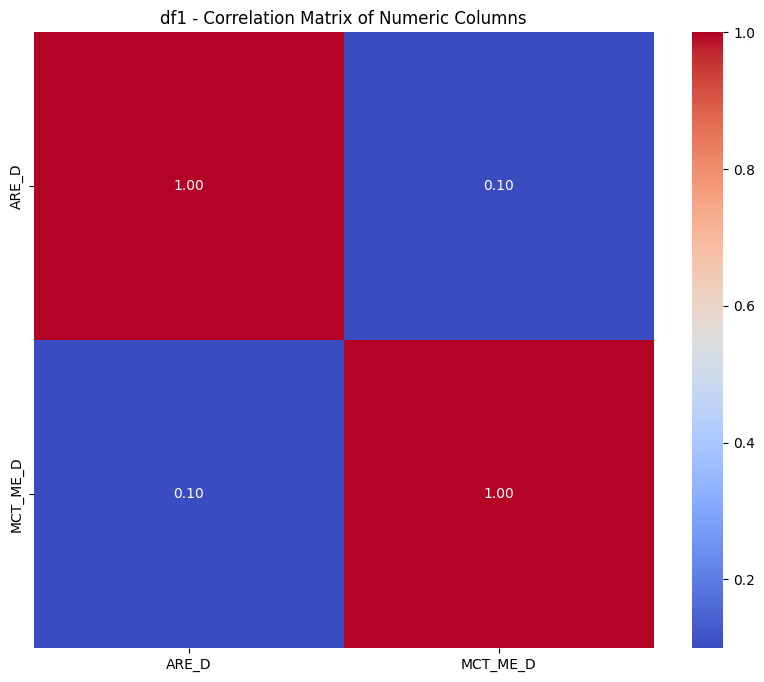

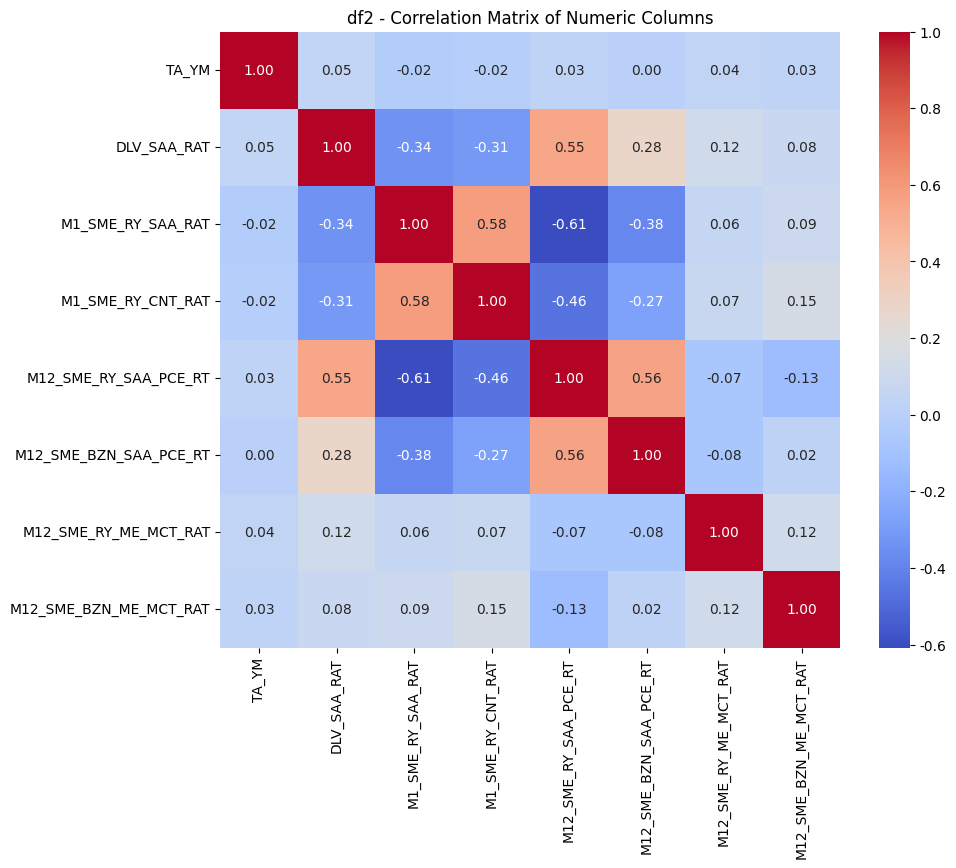

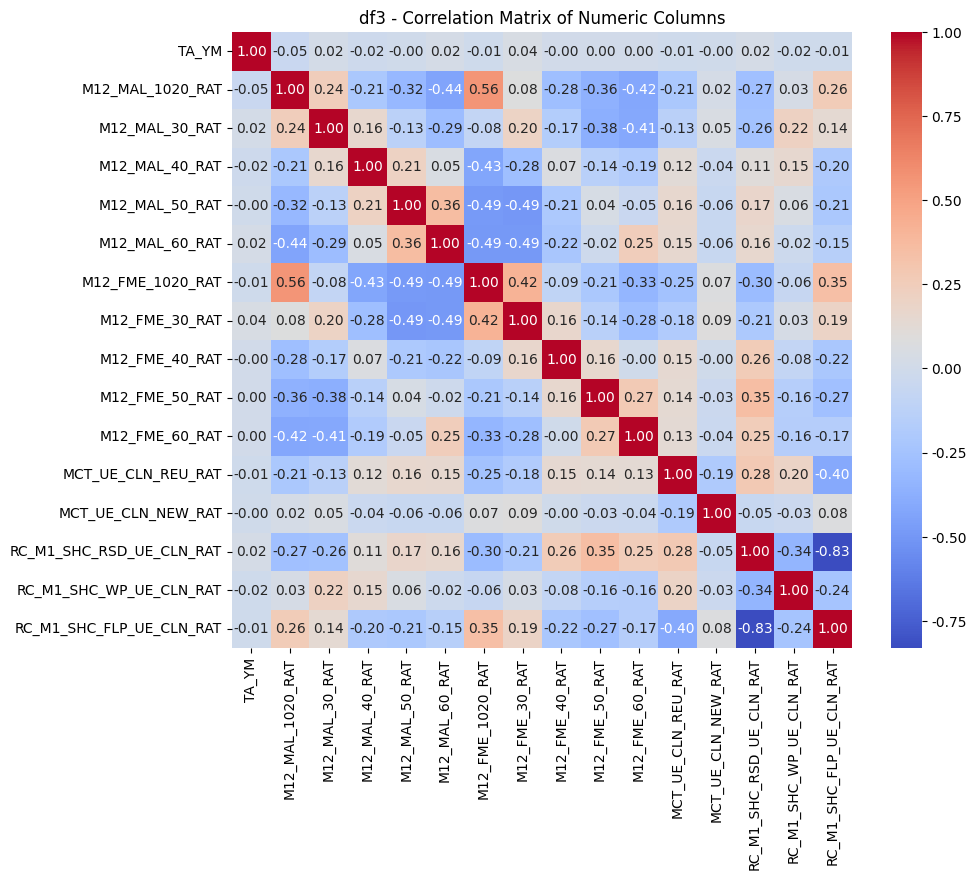

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to calculate and plot correlation matrix, handling placeholder values
def plot_correlation_heatmap(df, df_name):
    # Select numeric columns
    numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

    # Replace placeholder value with NaN before calculating correlation
    numeric_df = numeric_df.replace(-999999.9, np.nan)

    # Drop columns with all NaN values after replacing placeholder
    numeric_df = numeric_df.dropna(axis=1, how='all')

    if numeric_df.shape[1] > 1:
        # Calculate the correlation matrix
        correlation_matrix = numeric_df.corr()

        # Plot the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title(f'{df_name} - Correlation Matrix of Numeric Columns')
        plt.show()
    else:
        print(f"DataFrame {df_name} does not have enough numeric columns (after handling placeholders) to calculate correlation.")


# Plot correlation heatmap for each dataframe
plot_correlation_heatmap(df1, 'df1')
plot_correlation_heatmap(df2, 'df2')
plot_correlation_heatmap(df3, 'df3')

# 전처리

### df1

In [ ]:
# Split 'MCT_BSE_AR' into 4 columns, handling multiple spaces
df1[['MCT_BSE_AR_part1', 'MCT_BSE_AR_part2', 'MCT_BSE_AR_part3', 'MCT_BSE_AR_part4']] = df1['MCT_BSE_AR'].str.split(expand=True, n=3)

# Display the updated dataframe with the new columns
display(df1.head(20))

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN,서울,성동구,마장동,None
5,281CA527F1,서울 성동구 마장동,대광**,NaN,서울 성동구,축산물,마장동,20170222,NaN,서울,성동구,마장동,None
6,9A71D71270,서울 성동구 마장동,미림**,NaN,서울 성동구,식품 제조,NaN,20170817,NaN,서울,성동구,마장동,None
7,761947ABD9,서울 성동구 마장동,호남*,NaN,서울 성동구,한식-육류/고기,마장동,20130531,NaN,서울,성동구,마장동,None
8,145BA84596,서울 성동구 사근동,고향***,NaN,서울 성동구,한식-찌개/전골,한양대,20140618,NaN,서울,성동구,사근동,None
9,27C88660A5,서울 성동구 송정동,북*,NaN,서울 성동구,중식당,NaN,20141217,NaN,서울,성동구,송정동,None


In [ ]:
display(df1.head(20))

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN,서울,성동구,마장동,None
5,281CA527F1,서울 성동구 마장동,대광**,NaN,서울 성동구,축산물,마장동,20170222,NaN,서울,성동구,마장동,None
6,9A71D71270,서울 성동구 마장동,미림**,NaN,서울 성동구,식품 제조,NaN,20170817,NaN,서울,성동구,마장동,None
7,761947ABD9,서울 성동구 마장동,호남*,NaN,서울 성동구,한식-육류/고기,마장동,20130531,NaN,서울,성동구,마장동,None
8,145BA84596,서울 성동구 사근동,고향***,NaN,서울 성동구,한식-찌개/전골,한양대,20140618,NaN,서울,성동구,사근동,None
9,27C88660A5,서울 성동구 송정동,북*,NaN,서울 성동구,중식당,NaN,20141217,NaN,서울,성동구,송정동,None


In [ ]:
df1['MCT_BSE_AR_part1'].value_counts()

,count
MCT_BSE_AR_part1,
서울특별시,2787
서울,1397
경기,1


In [ ]:
df1['MCT_BSE_AR_part1'] = df1['MCT_BSE_AR_part1'].replace('서울특별시', '서울')

# Verify the change
display(df1['MCT_BSE_AR_part1'].value_counts())

,count
MCT_BSE_AR_part1,
서울,4184
경기,1


In [ ]:
df1['MCT_BSE_AR_part2'].value_counts()

,count
MCT_BSE_AR_part2,
성동구,4183
강남구,1
동두천시,1


In [ ]:
# Filter df1 to keep only rows where 'MCT_BSE_AR_part2' is '성동구'
df1_filtered = df1[df1['MCT_BSE_AR_part2'] == '성동구'].copy()

# Optionally, update the original df1 if desired
df1 = df1_filtered

# Display the value counts to verify the filtering
display(df1['MCT_BSE_AR_part2'].value_counts())

# Display the shape of the filtered dataframe to see how many rows were removed
print(f"Original df1 shape: {df1.shape}")
print(f"Filtered df1 shape: {df1_filtered.shape}")

,count
MCT_BSE_AR_part2,
성동구,4183


Original df1 shape: (4183, 13)
Filtered df1 shape: (4183, 13)


In [ ]:
df1['MCT_BSE_AR_part3'].value_counts()

,count
MCT_BSE_AR_part3,
왕십리로,236
독서당로,137
마장로,134
마조로,110
성덕정길,99
...,...
용답25나길,1
독서당로57길,1
왕십리로21다길,1


In [ ]:
df1['MCT_BSE_AR_part4'].value_counts()

,count
MCT_BSE_AR_part4,
410,74
17,72
11,63
6,60
8,55
...,...
8-18,1
157-31,1
363-1 (하왕십리동),1


In [ ]:
# Check for values containing '.' in 'MCT_BSE_AR_part4'
contains_dot = df1['MCT_BSE_AR_part4'].astype(str).str.contains(r'\.', na=False)
print(f"Number of values containing '.': {contains_dot.sum()}")

# Display some of the values containing '.' before replacement
if contains_dot.sum() > 0:
    print("Examples of values containing '.' before replacement:")
    display(df1.loc[contains_dot, 'MCT_BSE_AR_part4'].head())

# Remove '.' from the column
df1['MCT_BSE_AR_part4'] = df1['MCT_BSE_AR_part4'].astype(str).str.replace(r'\.', '', regex=True)

# Verify the change by checking if any value still contains '.'
contains_dot_after = df1['MCT_BSE_AR_part4'].astype(str).str.contains(r'\.', na=False)
print(f"\nNumber of values containing '.' after replacement: {contains_dot_after.sum()}")

# Display some of the values after replacement to confirm
print("Examples of values after replacement:")
display(df1.loc[contains_dot, 'MCT_BSE_AR_part4'].head())

Number of values containing '.': 831
Examples of values containing '.' before replacement:


,MCT_BSE_AR_part4
91,7.
92,2.
93,2.
121,17.
122,17.



Number of values containing '.' after replacement: 0
Examples of values after replacement:


,MCT_BSE_AR_part4
91,7
92,2
93,2
121,17
122,17


In [ ]:
df1 = df1.drop('MCT_BSE_AR', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN,서울,성동구,마장동,None


In [ ]:
df1['MCT_NM'].value_counts()

,count
MCT_NM,
성수**,31
카페***,16
성수****,12
카페**,11
서울**,10
...,...
스켓******,1
하람**,1
샐러****************,1


In [ ]:
df1 = df1.drop('MCT_NM', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,NaN,서울 성동구,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,NaN,서울 성동구,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,NaN,서울 성동구,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,NaN,서울 성동구,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,NaN,서울 성동구,축산물,마장동,20151211,NaN,서울,성동구,마장동,None


In [ ]:
df1['MCT_BRD_NUM'].value_counts()

,count
MCT_BRD_NUM,
커피전문점2,20
베이커리10,18
커피전문점6,14
커피전문점11,13
커피전문점4,10
...,...
치킨21,1
한식-냉면1,1
치킨19,1


In [ ]:
df1['MCT_SIGUNGU_NM'].value_counts()

,count
MCT_SIGUNGU_NM,
서울 성동구,4183


In [ ]:
df1 = df1.drop('MCT_SIGUNGU_NM', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,NaN,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,NaN,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,NaN,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,NaN,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,NaN,축산물,마장동,20151211,NaN,서울,성동구,마장동,None


In [ ]:
df1['HPSN_MCT_ZCD_NM'].value_counts().head(20)

,count
HPSN_MCT_ZCD_NM,
한식-육류/고기,442
카페,357
백반/가정식,346
한식-단품요리일반,306
축산물,285
커피전문점,182
양식,176
식료품,158
베이커리,146


In [ ]:
# 그룹화를 위한 매핑 정의
category_mapping = {
    '한식': ['한식-육류/고기', '백반/가정식', '한식-단품요리일반', '한식-해물/생선', '한식-국수/만두', '한식-국밥/설렁탕', '기사식당', '칼국수/만두', '한식-기타', '곰탕/설렁탕', '냉면', '추어탕', '국수', '비빔밥', '갈비/찜', '삼겹살', '샤브샤브', '족발/보쌈', '국밥', '해물찜/탕', '찌개/전골', '순대국', '감자탕', '불고기/두루치기', '쌈밥', '아구찜/탕', '칼국수', '백반', '삼계탕', '돌솥밥', '육개장/추어탕', '전/막걸리', '곱창/막창', '곰탕', '찜닭', '한식-찌개/전골', '반찬', '한정식', '한식-냉면', '한식-감자탕', '한식-죽', '한식뷔페', '한식-두부요리', '구내식당/푸드코너', '도시락', '떡/한과 제조', '떡/한과'], # '구내식당/푸드코너' 추가
    '카페/디저트': ['카페', '커피전문점', '베이커리', '아이스크림/빙수', '도넛', '와플/크로플', '케이크', '토스트', '샌드위치/토스트', '테마카페', '마카롱', '테이크아웃커피', '도너츠', '차'],
    '외국 음식': ['양식', '일식당', '중식당', '아시아음식', '패밀리레스토랑', '퓨전음식', '태국음식', '이탈리아음식', '스페인음식', '멕시코/남미음식', '인도음식', '프랑스음식', '동남아음식', '중국음식', '파스타/스파게티', '스테이크', '피자', '일식-덮밥/돈가스', '일식-우동/소바/라면', '기타세계요리', '일식-초밥/롤', '이자카야', '일식-샤브샤브', '일식-참치회', '중식-훠궈/마라탕', '중식-딤섬/중식만두', '동남아/인도음식'],
    '분식/간식': ['분식', '치킨', '호프/맥주', '요리주점', '패스트푸드', '제과점', '떡볶이', '닭강정', '핫도그', '꼬치구이', '튀김', '탕후루', '햄버거', '포장마차', '민속주점'],
    '식료품/기타': ['축산물', '식료품', '농산물', '수산물', '건강식품', '정육점', '청과', '수산시장', '반찬가게', '유제품', '기타', '식품 제조', '인삼제품', '미곡상', '주류', '주스', '건어물', '건강원', '일반 유흥주점', '와인바', '와인샵', '담배', '청과물', '룸살롱/단란주점']
}


# 매핑을 쉽게 찾을 수 있도록 역으로 변환
reverse_category_mapping = {item: key for key, values in category_mapping.items() for item in values}

# 매핑을 기반으로 새로운 컬럼 생성
df1['HPSN_MCT_ZCD_NM_CATEGORY'] = df1['HPSN_MCT_ZCD_NM'].map(reverse_category_mapping)

# 매핑되지 않은 값이 있는지 확인 (매핑에 없는 HPSN_MCT_ZCD_NM 값이 있는 경우)
unmapped_values = df1[df1['HPSN_MCT_ZCD_NM_CATEGORY'].isnull()]['HPSN_MCT_ZCD_NM'].unique()
if len(unmapped_values) > 0:
    print("경고: 다음 HPSN_MCT_ZCD_NM 값은 매핑되지 않았습니다:")
    print(unmapped_values)
else:
    print("모든 HPSN_MCT_ZCD_NM 값이 성공적으로 매핑되었습니다.")


# 새로운 카테고리 컬럼의 값 개수 확인
display(df1['HPSN_MCT_ZCD_NM_CATEGORY'].value_counts())

# 새로운 컬럼이 포함된 데이터프레임의 처음 부분 출력
display(df1[['HPSN_MCT_ZCD_NM', 'HPSN_MCT_ZCD_NM_CATEGORY']].head())

경고: 다음 HPSN_MCT_ZCD_NM 값은 매핑되지 않았습니다:
['구내식당/푸드코트']


,count
HPSN_MCT_ZCD_NM_CATEGORY,
한식,1505
카페/디저트,798
식료품/기타,730
외국 음식,615
분식/간식,533


,HPSN_MCT_ZCD_NM,HPSN_MCT_ZCD_NM_CATEGORY
0,축산물,식료품/기타
1,축산물,식료품/기타
2,축산물,식료품/기타
3,축산물,식료품/기타
4,축산물,식료품/기타


In [ ]:
df1 = df1.drop('HPSN_MCT_ZCD_NM', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY
0,16184E93D9,NaN,마장동,20130320,NaN,서울,성동구,마장동,None,식료품/기타
1,4D039EA8B7,NaN,마장동,20131122,NaN,서울,성동구,마장동,None,식료품/기타
2,0074C4990A,NaN,마장동,20140512,NaN,서울,성동구,마장동,None,식료품/기타
3,68308F2746,NaN,마장동,20151124,NaN,서울,성동구,마장동,None,식료품/기타
4,4117EDDE9C,NaN,마장동,20151211,NaN,서울,성동구,마장동,None,식료품/기타


In [ ]:
df1['HPSN_MCT_BZN_CD_NM'].value_counts().head(20)

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


In [ ]:
# HPSN_MCT_BZN_CD_NM 컬럼의 값별 개수를 계산
bzn_counts = df1['HPSN_MCT_BZN_CD_NM'].value_counts()

# 값이 한 번만 나타나는 HPSN_MCT_BZN_CD_NM 값들을 식별
single_occurrence_bzns = bzn_counts[bzn_counts == 1].index

# df1에서 값이 한 번만 나타나는 HPSN_MCT_BZN_CD_NM를 포함하는 행들을 제외하고 필터링
df1_filtered = df1[~df1['HPSN_MCT_BZN_CD_NM'].isin(single_occurrence_bzns)].copy()

# 원본 df1을 필터링된 데이터프레임으로 업데이트 (원하는 경우)
df1 = df1_filtered

# 제거 후 HPSN_MCT_BZN_CD_NM 컬럼의 값 개수를 다시 확인 (상위 20개)
display(df1['HPSN_MCT_BZN_CD_NM'].value_counts().head(20))

# 필터링된 데이터프레임의 행 개수를 확인하여 몇 개의 행이 제거되었는지 확인
print(f"원본 df1 형태: {df1.shape}")
print(f"필터링된 df1 형태: {df1_filtered.shape}")

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


원본 df1 형태: (4173, 10)
필터링된 df1 형태: (4173, 10)


In [ ]:
df1['ARE_D'].value_counts().head(20)

,count
ARE_D,
20220622,7
20221031,7
20231005,7
20240426,7
20210709,7
20240509,7
20220418,6
20230927,6
20211208,6


In [ ]:
# ARE_D 컬럼을 문자열로 변환하고 datetime 형식으로 변환 (errors='coerce'를 사용하여 변환 불가능한 값은 NaT 처리)
df1['ARE_D_datetime'] = pd.to_datetime(df1['ARE_D'].astype(str), format='%Y%m%d', errors='coerce')

# datetime 컬럼에서 연, 월, 일 추출하여 새로운 컬럼 생성
df1['ARE_D_year'] = df1['ARE_D_datetime'].dt.year
df1['ARE_D_month'] = df1['ARE_D_datetime'].dt.month
df1['ARE_D_day'] = df1['ARE_D_datetime'].dt.day

# 원래 ARE_D 컬럼과 새로 생성된 컬럼들을 함께 출력하여 확인
display(df1[['ARE_D', 'ARE_D_year', 'ARE_D_month', 'ARE_D_day', 'ARE_D_datetime']].head())

# 변환 중 발생한 NaT 값 (원래 ARE_D 값 중 유효하지 않은 날짜 형식)이 있는지 확인
if df1['ARE_D_datetime'].isnull().sum() > 0:
    print(f"경고: ARE_D 컬럼 변환 중 {df1['ARE_D_datetime'].isnull().sum()}개의 유효하지 않은 날짜 형식이 발견되어 NaT로 처리되었습니다.")

,ARE_D,ARE_D_year,ARE_D_month,ARE_D_day,ARE_D_datetime
0,20130320,2013,3,20,2013-03-20
1,20131122,2013,11,22,2013-11-22
2,20140512,2014,5,12,2014-05-12
3,20151124,2015,11,24,2015-11-24
4,20151211,2015,12,11,2015-12-11


In [ ]:
df1 = df1.drop('ARE_D', axis=1)
df1 = df1.drop('ARE_D_datetime', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day
0,16184E93D9,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2013,3,20
1,4D039EA8B7,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2013,11,22
2,0074C4990A,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2014,5,12
3,68308F2746,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2015,11,24
4,4117EDDE9C,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2015,12,11


In [ ]:
df1['MCT_ME_D'].value_counts().head(30)

,count
MCT_ME_D,
20250811.0,7
20250730.0,6
20250801.0,5
20250731.0,4
20250728.0,4
20250721.0,4
20250814.0,4
20250714.0,4
20250808.0,3


In [ ]:
# from datetime import date
# import pandas as pd
# import numpy as np

# # 'MCT_ME_D' 컬럼을 처리하여 datetime 형식으로 변환
# # 1. 결측치(NaN)를 식별합니다.
# # 2. 결측치가 아닌 값에 대해 정수형으로 변환합니다 (부동 소수점 .0 제거).
# # 3. 문자열로 변환합니다.
# # 4. datetime 형식으로 변환합니다 (errors='coerce'를 사용하여 변환 불가능한 값은 NaT 처리).
# # 이 과정을 통해 '20250714.0'과 같은 값이 '20250714' 문자열을 거쳐 유효한 날짜로 변환되도록 합니다.
# df1['MCT_ME_D_date'] = pd.to_datetime(
#     df1['MCT_ME_D'].dropna().astype(int).astype(str),
#     format='%Y%m%d',
#     errors='coerce'
# )

In [ ]:
# 2025년 7월 1일 이후의 MCT_ME_D 값만을 사용해서, 폐업여부 칼럼을 생성하는 코드


# from datetime import date
# import pandas as pd
# import numpy as np

# # 기준일 설정 (2025년 7월 1일)
# prediction_cutoff_date = pd.to_datetime(date(2025, 7, 1))

# # 'MCT_ME_D' 컬럼을 처리하여 datetime 형식으로 변환
# # 1. 결측치(NaN)를 식별합니다.
# # 2. 결측치가 아닌 값에 대해 정수형으로 변환합니다 (부동 소수점 .0 제거).
# # 3. 문자열로 변환합니다.
# # 4. datetime 형식으로 변환합니다 (errors='coerce'를 사용하여 변환 불가능한 값은 NaT 처리).
# # 이 과정을 통해 '20250714.0'과 같은 값이 '20250714' 문자열을 거쳐 유효한 날짜로 변환되도록 합니다.
# df1['MCT_ME_D_date'] = pd.to_datetime(
#     df1['MCT_ME_D'].dropna().astype(int).astype(str),
#     format='%Y%m%d',
#     errors='coerce'
# )

# # 원본 df1에 'MCT_ME_D_date' 컬럼을 다시 정렬하여 할당 (결측치 포함)
# df1['MCT_ME_D_date'] = df1['MCT_ME_D_date'].reindex(df1.index)


# # 'MCT_ME_CLOSED' 컬럼 재정의:
# # 'MCT_ME_D_date' 값이 존재하고(폐업했으며) 기준일 (2025년 7월 1일) 이후인 경우 1 (미래 폐업)
# # 그 외의 경우 0 (미래 폐업 아님 - 폐업하지 않았거나 기준일 이전에 폐업)
# df1['MCT_ME_CLOSED'] = ((df1['MCT_ME_D_date'].notnull()) & (df1['MCT_ME_D_date'] >= prediction_cutoff_date)).astype(int)


# # 새로 생성된 'MCT_ME_CLOSED' 컬럼의 값 개수를 확인
# print("'MCT_ME_CLOSED' 컬럼 값 개수 (재정의 후):")
# display(df1['MCT_ME_CLOSED'].value_counts())

# # 데이터프레임의 처음 부분을 출력하여 변경 확인
# display(df1.head())

# # 'MCT_ME_D_date' 컬럼은 더 이상 필요 없으므로 삭제합니다.
# df1 = df1.drop('MCT_ME_D_date', axis=1)

# # 최종 df1 확인
# display(df1.head())

In [ ]:
df1 = df1.drop('MCT_ME_D', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day
0,16184E93D9,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,3,20
1,4D039EA8B7,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,11,22
2,0074C4990A,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2014,5,12
3,68308F2746,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,11,24
4,4117EDDE9C,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,12,11


In [ ]:
display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day
0,16184E93D9,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,3,20
1,4D039EA8B7,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,11,22
2,0074C4990A,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2014,5,12
3,68308F2746,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,11,24
4,4117EDDE9C,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,12,11


In [ ]:
# df1 데이터프레임의 각 컬럼별 결측치 개수 계산
missing_values_df1 = df1.isnull().sum()

# 결측치가 있는 컬럼만 필터링하여 출력 (모든 컬럼을 보려면 필터링 제거)
print("df1 컬럼별 결측치 개수:")
display(missing_values_df1[missing_values_df1 > 0])

df1 컬럼별 결측치 개수:


,0
MCT_BRD_NUM,3632
HPSN_MCT_BZN_CD_NM,1046
HPSN_MCT_ZCD_NM_CATEGORY,2


HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM 결측 비율:


,MCT_BRD_NUM_isnull
HPSN_MCT_ZCD_NM_CATEGORY,
식료품/기타,0.965659
외국 음식,0.918301
한식,0.902130
카페/디저트,0.789210
분식/간식,0.716165


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Using font: ['NanumGothic']


/tmp/ipython-input-1040814162.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_rate_by_category.index, y=missing_rate_by_category.values, palette='viridis')


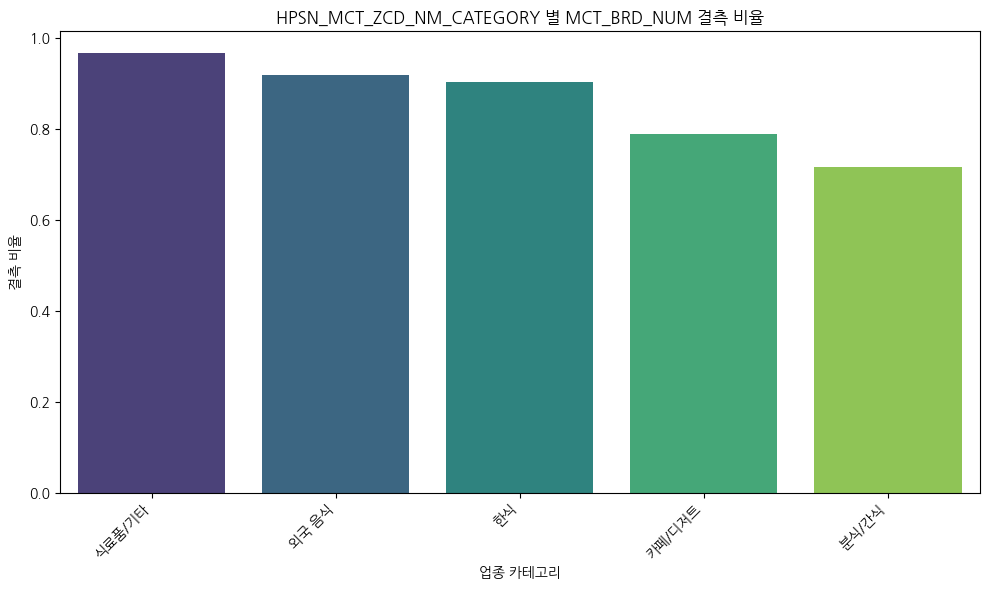

In [ ]:
# HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM의 결측 여부 확인
# True는 결측, False는 값 존재
df1['MCT_BRD_NUM_isnull'] = df1['MCT_BRD_NUM'].isnull()

# HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM 결측 비율 계산
missing_rate_by_category = df1.groupby('HPSN_MCT_ZCD_NM_CATEGORY')['MCT_BRD_NUM_isnull'].mean().sort_values(ascending=False)

# 결과 출력
print("HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM 결측 비율:")
display(missing_rate_by_category)

# 결측 여부 임시 컬럼 제거
df1 = df1.drop('MCT_BRD_NUM_isnull', axis=1)

# 결측 비율 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 나눔고딕 폰트 설치 (코랩 환경)
!apt-get update -qq
!apt-get install fonts-nanum -qq > /dev/null

# 설치된 폰트 캐시 재설정
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print(f"Using font: {plt.rcParams['font.family']}")


plt.figure(figsize=(10, 6))
sns.barplot(x=missing_rate_by_category.index, y=missing_rate_by_category.values, palette='viridis')
plt.title('HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM 결측 비율')
plt.ylabel('결측 비율')
plt.xlabel('업종 카테고리')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# # MCT_BRD_NUM 컬럼의 결측치(NaN)를 문자열 'None'으로 채우기
# df1['MCT_BRD_NUM'] = df1['MCT_BRD_NUM'].fillna('None')

# # 변경 확인을 위해 결측치 개수 다시 확인
# print("MCT_BRD_NUM 컬럼의 결측치 개수 (None으로 채운 후):")
# display(df1['MCT_BRD_NUM'].isnull().sum())

# # 변경된 데이터프레임의 처음 부분 확인
# display(df1.head())

In [ ]:
df1['HPSN_MCT_BZN_CD_NM'].value_counts().head(20)

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


In [ ]:
# # HPSN_MCT_BZN_CD_NM 컬럼의 결측치(NaN)를 문자열 'None'으로 채우기
# df1['HPSN_MCT_BZN_CD_NM'] = df1['HPSN_MCT_BZN_CD_NM'].fillna('None')

# # 변경 확인을 위해 결측치 개수 다시 확인
# print("HPSN_MCT_BZN_CD_NM 컬럼의 결측치 개수 (None으로 채운 후):")
# display(df1['HPSN_MCT_BZN_CD_NM'].isnull().sum())

# # 변경된 데이터프레임의 처음 부분 확인
# display(df1.head())

In [ ]:
display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day
0,16184E93D9,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,3,20
1,4D039EA8B7,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,11,22
2,0074C4990A,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2014,5,12
3,68308F2746,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,11,24
4,4117EDDE9C,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,12,11


In [ ]:
# Filter rows where 'HPSN_MCT_ZCD_NM_CATEGORY' is null
missing_category_rows = df1[df1['HPSN_MCT_ZCD_NM_CATEGORY'].isnull()]

# Display the relevant columns for these rows
# Displaying all columns might be too wide, so let's select a few informative ones
display(missing_category_rows[['ENCODED_MCT', 'MCT_BRD_NUM', 'HPSN_MCT_BZN_CD_NM', 'HPSN_MCT_ZCD_NM_CATEGORY', 'ARE_D_year', 'ARE_D_month', 'ARE_D_day']]) # 'MCT_ME_CLOSED'

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day
1932,C8BFE622A5,NaN,성수,NaN,2023,9,27
2165,56CE6776C6,NaN,왕십리,NaN,2022,9,20


In [ ]:
# HPSN_MCT_ZCD_NM_CATEGORY 컬럼에 결측치가 없는 행만 남기고 필터링
df1_filtered = df1.dropna(subset=['HPSN_MCT_ZCD_NM_CATEGORY']).copy()

# 원본 df1을 필터링된 데이터프레임으로 업데이트
df1 = df1_filtered

# 변경 후 HPSN_MCT_ZCD_NM_CATEGORY 결측치 개수 확인
print(f"HPSN_MCT_ZCD_NM_CATEGORY 결측치 개수 (삭제 후): {df1['HPSN_MCT_ZCD_NM_CATEGORY'].isnull().sum()}")

# 필터링된 데이터프레임의 행 개수를 확인하여 몇 개의 행이 제거되었는지 확인
print(f"원본 df1 형태: {df1.shape}")
print(f"필터링된 df1 형태: {df1_filtered.shape}")

HPSN_MCT_ZCD_NM_CATEGORY 결측치 개수 (삭제 후): 0
원본 df1 형태: (4171, 11)
필터링된 df1 형태: (4171, 11)


### df2

In [ ]:
df2.head()

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


In [ ]:
# 각 컬럼의 고유값 확인
print("MCT_OPE_MS_CN 고유값:")
display(df2['MCT_OPE_MS_CN'].value_counts().sort_index())

print("\nRC_M1_SAA 고유값:")
display(df2['RC_M1_SAA'].value_counts().sort_index())

print("\nRC_M1_TO_UE_CT 고유값:")
display(df2['RC_M1_TO_UE_CT'].value_counts().sort_index())

print("\nRC_M1_UE_CUS_CN 고유값:")
display(df2['RC_M1_UE_CUS_CN'].value_counts().sort_index())

print("\nRC_M1_AV_NP_AT 고유값:")
display(df2['RC_M1_AV_NP_AT'].value_counts().sort_index())

print("\nAPV_CE_RAT 고유값:")
display(df2['APV_CE_RAT'].value_counts().sort_index())

MCT_OPE_MS_CN 고유값:


,count
MCT_OPE_MS_CN,
1_10%이하,8691
2_10-25%,13119
3_25-50%,21812
4_50-75%,21567
5_75-90%,13454
6_90%초과(하위 10% 이하),7947



RC_M1_SAA 고유값:


,count
RC_M1_SAA,
1_10%이하,8799
2_10-25%,13167
3_25-50%,21800
4_50-75%,21692
5_75-90%,12912
6_90%초과(하위 10% 이하),8220



RC_M1_TO_UE_CT 고유값:


...

,count
RC_M1_UE_CUS_CN,
1_10%이하,8771
2_10-25%,13147
3_25-50%,21934
4_50-75%,22026
5_75-90%,14001
6_90%초과(하위 10% 이하),6711



RC_M1_AV_NP_AT 고유값:


,count
RC_M1_AV_NP_AT,
1_10%이하,8690
2_10-25%,13143
3_25-50%,21918
4_50-75%,21781
5_75-90%,12888
6_90%초과(하위 10% 이하),8170



APV_CE_RAT 고유값:


,count
APV_CE_RAT,
1_상위1구간,52445
2_상위2구간,4994
3_상위3구간,5457
4_상위4구간,5551
5_상위5구간,5697
6_상위6구간(하위1구간),5814


In [ ]:
# 순서형 범주형 컬럼들에 대한 매핑 정의 (숫자가 작을수록 좋은 의미이므로, 숫자가 클수록 좋은 의미가 되도록 역매핑)
# 예: 1_10%이하 -> 6, 6_90%초과(하위 10% 이하) -> 1
mapping = {
    '1_10%이하': 6,
    '2_10-25%': 5,
    '3_25-50%': 4,
    '4_50-75%': 3,
    '5_75-90%': 2,
    '6_90%초과(하위 10% 이하)': 1
}

# APV_CE_RAT 컬럼에 대한 매핑 정의 (상위 구간일수록 좋은 의미이므로, 숫자가 클수록 좋은 의미가 되도록 역매핑)
# 예: 1_상위1구간 -> 6, 6_상위6구간(하위1구간) -> 1
apv_mapping = {
    '1_상위1구간': 6,
    '2_상위2구간': 5,
    '3_상위3구간': 4,
    '4_상위4구간': 3,
    '5_상위5구간': 2,
    '6_상위6구간(하위1구간)': 1
}


# 매핑을 적용할 컬럼 목록
columns_to_map = ['MCT_OPE_MS_CN', 'RC_M1_SAA', 'RC_M1_TO_UE_CT', 'RC_M1_UE_CUS_CN', 'RC_M1_AV_NP_AT']

# 지정된 컬럼들에 매핑 적용
for col in columns_to_map:
    df2[col + '_mapped'] = df2[col].replace(mapping)

# APV_CE_RAT 컬럼에 매핑 적용
df2['APV_CE_RAT_mapped'] = df2['APV_CE_RAT'].replace(apv_mapping)


# 변환된 컬럼들과 원본 컬럼 일부를 함께 출력하여 확인
display(df2[['MCT_OPE_MS_CN', 'MCT_OPE_MS_CN_mapped',
             'RC_M1_SAA', 'RC_M1_SAA_mapped',
             'APV_CE_RAT', 'APV_CE_RAT_mapped']].head())

# 변환된 컬럼들의 데이터 타입 확인
print("\n변환된 컬럼들의 데이터 타입:")
print(df2[['MCT_OPE_MS_CN_mapped', 'RC_M1_SAA_mapped', 'APV_CE_RAT_mapped']].dtypes)

/tmp/ipython-input-99909987.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col + '_mapped'] = df2[col].replace(mapping)
/tmp/ipython-input-99909987.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col + '_mapped'] = df2[col].replace(mapping)
/tmp/ipython-input-99909987.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('fut

,MCT_OPE_MS_CN,MCT_OPE_MS_CN_mapped,RC_M1_SAA,RC_M1_SAA_mapped,APV_CE_RAT,APV_CE_RAT_mapped
0,4_50-75%,3,5_75-90%,2,1_상위1구간,6.0
1,4_50-75%,3,6_90%초과(하위 10% 이하),1,NaN,NaN
2,2_10-25%,5,3_25-50%,4,6_상위6구간(하위1구간),1.0
3,2_10-25%,5,3_25-50%,4,6_상위6구간(하위1구간),1.0
4,2_10-25%,5,4_50-75%,3,1_상위1구간,6.0



변환된 컬럼들의 데이터 타입:
MCT_OPE_MS_CN_mapped      int64
RC_M1_SAA_mapped          int64
APV_CE_RAT_mapped       float64
dtype: object


In [ ]:
# 삭제할 컬럼 목록
columns_to_drop_df2 = ['MCT_OPE_MS_CN', 'RC_M1_SAA', 'RC_M1_TO_UE_CT', 'RC_M1_UE_CUS_CN', 'RC_M1_AV_NP_AT', 'APV_CE_RAT']

# df2에서 지정된 컬럼 삭제
df2 = df2.drop(columns=columns_to_drop_df2)

# 변경된 데이터프레임의 처음 부분을 출력하여 확인
display(df2.head())

,ENCODED_MCT,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,RC_M1_UE_CUS_CN_mapped,RC_M1_AV_NP_AT_mapped,APV_CE_RAT_mapped
0,000F03E44A,202404,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8,3,2,2,2,2,6.0
1,000F03E44A,202312,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2,3,1,1,1,1,NaN
2,002816BA73,202404,-999999.9,96.6,40.8,15.6,20.0,17.5,5.2,5,4,3,3,5,1.0
3,002816BA73,202411,-999999.9,108.0,46.4,16.8,19.8,16.9,6.9,5,4,3,3,5,1.0
4,002816BA73,202406,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6,5,3,3,3,5,6.0


In [ ]:
# Replace -999999.9 with 0 in the specified columns
df2['DLV_SAA_RAT'] = df2['DLV_SAA_RAT'].replace(-999999.9, 0)
df2['M12_SME_BZN_ME_MCT_RAT'] = df2['M12_SME_BZN_ME_MCT_RAT'].replace(-999999.9, 0)

# Verify the change by checking the minimum value and value counts of -999999.9
print("DLV_SAA_RAT 컬럼의 최소값 (변경 후):")
display(df2['DLV_SAA_RAT'].min())

print("\nM12_SME_BZN_ME_MCT_RAT 컬럼의 최소값 (변경 후):")
display(df2['M12_SME_BZN_ME_MCT_RAT'].min()) # Corrected column name

print("\nDLV_SAA_RAT 컬럼에서 -999999.9 값 개수 (변경 후):")
display(df2[df2['DLV_SAA_RAT'] == -999999.9].shape[0])

print("\nM12_SME_BZN_ME_MCT_RAT 컬럼에서 -999999.9 값 개수 (변경 후):")
display(df2[df2['M12_SME_BZN_ME_MCT_RAT'] == -999999.9].shape[0])

# 데이터프레임의 처음 부분을 출력하여 변경 확인
display(df2.head())

DLV_SAA_RAT 컬럼의 최소값 (변경 후):


0.0


M12_SME_BZN_ME_MCT_RAT 컬럼의 최소값 (변경 후):


0.0


DLV_SAA_RAT 컬럼에서 -999999.9 값 개수 (변경 후):


0


M12_SME_BZN_ME_MCT_RAT 컬럼에서 -999999.9 값 개수 (변경 후):


0

,ENCODED_MCT,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,RC_M1_UE_CUS_CN_mapped,RC_M1_AV_NP_AT_mapped,APV_CE_RAT_mapped
0,000F03E44A,202404,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,2,2,2,2,6.0
1,000F03E44A,202312,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,1,1,1,1,NaN
2,002816BA73,202404,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,4,3,3,5,1.0
3,002816BA73,202411,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,4,3,3,5,1.0
4,002816BA73,202406,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,3,3,3,5,6.0


### df3

In [ ]:
df3.head(20)

,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.00,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.00,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.00,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.00,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.00,-999999.9,-999999.9,-999999.9
5,055EDDDD01,202311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,50.0,33.33,0.00,-999999.9,-999999.9,-999999.9
6,06A87DAA45,202411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.00,0.00,0.0,100.0,0.0
7,06A87DAA45,202310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.00,0.00,-999999.9,-999999.9,-999999.9
8,06A87DAA45,202312,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.00,0.00,-999999.9,-999999.9,-999999.9
9,09D2771DD5,202406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.00,0.00,-999999.9,-999999.9,-999999.9


In [ ]:
# Replace -999999.9 with 0 in all columns of df3
df3 = df3.replace(-999999.9, 0)

# Verify the change by checking the minimum values in numeric columns
print("df3 수치형 컬럼들의 최소값 (변경 후):")
display(df3.select_dtypes(include=np.number).min())

# Check if -999999.9 still exists in any column
print("\ndf3에서 -999999.9 값이 존재하는 컬럼 (변경 후):")
cols_with_placeholder = [(col, (df3[col] == -999999.9).sum()) for col in df3.columns if (df3[col] == -999999.9).sum() > 0]
if cols_with_placeholder:
    display(cols_with_placeholder)
else:
    print("모든 -999999.9 값이 성공적으로 대체되었습니다.")


# 데이터프레임의 처음 부분을 출력하여 변경 확인
display(df3.head())

df3 수치형 컬럼들의 최소값 (변경 후):


,0
TA_YM,202301.0
M12_MAL_1020_RAT,0.0
M12_MAL_30_RAT,0.0
M12_MAL_40_RAT,0.0
M12_MAL_50_RAT,0.0
M12_MAL_60_RAT,0.0
M12_FME_1020_RAT,0.0
M12_FME_30_RAT,0.0
M12_FME_40_RAT,0.0
M12_FME_50_RAT,0.0



df3에서 -999999.9 값이 존재하는 컬럼 (변경 후):
모든 -999999.9 값이 성공적으로 대체되었습니다.


,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,0.0,0.0,0.0
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,0.0,0.0,0.0
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,0.0,0.0,0.0
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,0.0,0.0,0.0


In [ ]:
# df3 데이터프레임의 각 컬럼별 결측치 개수 계산
missing_values_df3 = df3.isnull().sum()

# 결측치가 있는 컬럼만 필터링하여 출력
print("df3 컬럼별 결측치 개수:")
display(missing_values_df3[missing_values_df3 > 0])

df3 컬럼별 결측치 개수:


,0


### 통합 및 추가 전처리

In [ ]:
# df2와 df3를 'ENCODED_MCT'와 'TA_YM' 기준으로 내부 조인 (inner join)
# 두 데이터프레임에 모두 존재하는 가맹점과 월의 데이터만 남깁니다.
merged_df = pd.merge(df2, df3, on=['ENCODED_MCT', 'TA_YM'], how='inner')

# df1과 이전 결과를 'ENCODED_MCT' 기준으로 내부 조인
# df1에 존재하는 가맹점의 데이터만 남깁니다.
final_df = pd.merge(merged_df, df1, on='ENCODED_MCT', how='inner')

# 결합된 데이터프레임의 정보와 처음 부분을 출력하여 확인
print("결합된 데이터프레임 정보:")
display(final_df.info())

print("\n결합된 데이터프레임 처음 5행:")
display(final_df.head())

결합된 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86295 entries, 0 to 86294
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86295 non-null  object 
 1   TA_YM                     86295 non-null  int64  
 2   DLV_SAA_RAT               86295 non-null  float64
 3   M1_SME_RY_SAA_RAT         86295 non-null  float64
 4   M1_SME_RY_CNT_RAT         86295 non-null  float64
 5   M12_SME_RY_SAA_PCE_RT     86295 non-null  float64
 6   M12_SME_BZN_SAA_PCE_RT    86295 non-null  float64
 7   M12_SME_RY_ME_MCT_RAT     86295 non-null  float64
 8   M12_SME_BZN_ME_MCT_RAT    86295 non-null  float64
 9   MCT_OPE_MS_CN_mapped      86295 non-null  int64  
 10  RC_M1_SAA_mapped          86295 non-null  int64  
 11  RC_M1_TO_UE_CT_mapped     86295 non-null  int64  
 12  RC_M1_UE_CUS_CN_mapped    86295 non-null  int64  
 13  RC_M1_AV_NP_AT_mapped     86295 non-null  int6

None


결합된 데이터프레임 처음 5행:


,ENCODED_MCT,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,...,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day
0,000F03E44A,202404,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,...,NaN,뚝섬,서울,성동구,왕십리로4가길,9,외국 음식,2022,2,25
1,000F03E44A,202312,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,...,NaN,뚝섬,서울,성동구,왕십리로4가길,9,외국 음식,2022,2,25
2,002816BA73,202404,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,...,NaN,마장동,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7
3,002816BA73,202411,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,...,NaN,마장동,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7
4,002816BA73,202406,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,...,NaN,마장동,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7


In [ ]:
# Convert 'TA_YM' to string and then to datetime format (YYYYMM)
final_df['TA_YM_datetime'] = pd.to_datetime(final_df['TA_YM'].astype(str), format='%Y%m', errors='coerce')

# Extract year and month into new columns
final_df['TA_year'] = final_df['TA_YM_datetime'].dt.year
final_df['TA_month'] = final_df['TA_YM_datetime'].dt.month

# Display the head of the dataframe with the new columns
display(final_df[['TA_YM', 'TA_year', 'TA_month', 'TA_YM_datetime']].head())

# Check for any values that couldn't be converted
if final_df['TA_YM_datetime'].isnull().sum() > 0:
    print(f"경고: TA_YM 컬럼 변환 중 {final_df['TA_YM_datetime'].isnull().sum()}개의 유효하지 않은 날짜 형식이 발견되어 NaT로 처리되었습니다.")

,TA_YM,TA_year,TA_month,TA_YM_datetime
0,202404,2024,4,2024-04-01
1,202312,2023,12,2023-12-01
2,202404,2024,4,2024-04-01
3,202411,2024,11,2024-11-01
4,202406,2024,6,2024-06-01


In [ ]:
final_df = final_df.drop('TA_YM', axis=1)
final_df = final_df.drop('TA_YM_datetime', axis=1)

display(final_df.head())

,ENCODED_MCT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,...,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,TA_year,TA_month
0,000F03E44A,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,2,...,서울,성동구,왕십리로4가길,9,외국 음식,2022,2,25,2024,4
1,000F03E44A,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,1,...,서울,성동구,왕십리로4가길,9,외국 음식,2022,2,25,2023,12
2,002816BA73,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,4,...,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7,2024,4
3,002816BA73,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,4,...,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7,2024,11
4,002816BA73,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,3,...,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7,2024,6


#### 개점경과일수 추가

In [ ]:
# 개점경과일수 ARE_Duration 칼럼 생성 (2025/07/01 기준)
# 그러나 MCT_OPE_MS_CN(가맹점 운영개월수 구간) 과 의미가 겹치는감? > 하지만 구간은 아닌 좀더 구체적인값

from datetime import date

# 개점일을 datetime 객체로 생성 (errors='coerce'를 사용하여 유효하지 않은 날짜는 NaT 처리)
final_df['ARE_D_date'] = pd.to_datetime(final_df[['ARE_D_year', 'ARE_D_month', 'ARE_D_day']].rename(columns={'ARE_D_year': 'year', 'ARE_D_month': 'month', 'ARE_D_day': 'day'}), errors='coerce')

# 기준일 (2025년 7월 1일) 설정
reference_date = date(2025, 7, 1)

# 개점 경과 일수 계산 (기준일 - 개점일)
# 결과는 timedelta 형태로 반환되므로 .dt.days를 사용하여 일(day) 단위로 변환
final_df['ARE_Duration'] = (pd.to_datetime(reference_date) - final_df['ARE_D_date']).dt.days

# 계산 결과 및 새로운 컬럼 확인
display(final_df[['ARE_D_year', 'ARE_D_month', 'ARE_D_day', 'ARE_D_date', 'ARE_Duration']].head())

# 변환 중 발생한 NaT 값 (원래 ARE_D 값 중 유효하지 않은 날짜 형식)이 있는지 확인
if final_df['ARE_D_date'].isnull().sum() > 0:
    print(f"경고: 개점일 변환 중 {final_df['ARE_D_date'].isnull().sum()}개의 유효하지 않은 날짜 형식이 발견되어 NaT로 처리되었습니다.")

# ARE_D_date 컬럼은 더 이상 필요 없으므로 삭제합니다.
final_df = final_df.drop('ARE_D_date', axis=1)

# 최종 데이터프레임의 처음 부분을 출력하여 변경 확인
display(final_df.head())

,ARE_D_year,ARE_D_month,ARE_D_day,ARE_D_date,ARE_Duration
0,2022,2,25,2022-02-25,1222
1,2022,2,25,2022-02-25,1222
2,2014,5,7,2014-05-07,4073
3,2014,5,7,2014-05-07,4073
4,2014,5,7,2014-05-07,4073


,ENCODED_MCT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,...,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,TA_year,TA_month,ARE_Duration
0,000F03E44A,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,2,...,성동구,왕십리로4가길,9,외국 음식,2022,2,25,2024,4,1222
1,000F03E44A,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,1,...,성동구,왕십리로4가길,9,외국 음식,2022,2,25,2023,12,1222
2,002816BA73,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,4,...,성동구,청계천로10나길,78,분식/간식,2014,5,7,2024,4,4073
3,002816BA73,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,4,...,성동구,청계천로10나길,78,분식/간식,2014,5,7,2024,11,4073
4,002816BA73,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,3,...,성동구,청계천로10나길,78,분식/간식,2014,5,7,2024,6,4073


#### 전월대비 변화량 추가

In [ ]:
columns_for_rank_change = [
    'RC_M1_SAA_mapped',
    'RC_M1_TO_UE_CT_mapped',
    'RC_M1_UE_CUS_CN_mapped',
    'RC_M1_AV_NP_AT_mapped',
    'APV_CE_RAT_mapped'
]

for col in columns_for_rank_change:
    # ENCODED_MCT 별로 그룹화하고 TA_year, TA_month로 정렬한 후 전월 값과의 차이 계산
    # 숫자가 큰게 좋은 순위이므로, 차이에 -1을 곱하여 순위 하락 시 음수 값이 되도록 함
    final_df[col + '_rank_change'] = final_df.groupby('ENCODED_MCT')[col].diff().fillna(0) * -1

# 생성된 새로운 컬럼들과 원본 컬럼 일부를 함께 출력하여 확인
display(final_df[['ENCODED_MCT', 'TA_year', 'TA_month'] + columns_for_rank_change + [col + '_rank_change' for col in columns_for_rank_change]].head())

# 새로운 컬럼들의 기초 통계량 확인
print("\n생성된 _rank_change 컬럼들의 기초 통계량:")
display(final_df[[col + '_rank_change' for col in columns_for_rank_change]].describe())

,ENCODED_MCT,TA_year,TA_month,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,RC_M1_UE_CUS_CN_mapped,RC_M1_AV_NP_AT_mapped,APV_CE_RAT_mapped,RC_M1_SAA_mapped_rank_change,RC_M1_TO_UE_CT_mapped_rank_change,RC_M1_UE_CUS_CN_mapped_rank_change,RC_M1_AV_NP_AT_mapped_rank_change,APV_CE_RAT_mapped_rank_change
0,000F03E44A,2024,4,2,2,2,2,6.0,-0.0,-0.0,-0.0,-0.0,-0.0
1,000F03E44A,2023,12,1,1,1,1,NaN,1.0,1.0,1.0,1.0,-0.0
2,002816BA73,2024,4,4,3,3,5,1.0,-0.0,-0.0,-0.0,-0.0,-0.0
3,002816BA73,2024,11,4,3,3,5,1.0,-0.0,-0.0,-0.0,-0.0,-0.0
4,002816BA73,2024,6,3,3,3,5,6.0,1.0,-0.0,-0.0,-0.0,-5.0



생성된 _rank_change 컬럼들의 기초 통계량:


,RC_M1_SAA_mapped_rank_change,RC_M1_TO_UE_CT_mapped_rank_change,RC_M1_UE_CUS_CN_mapped_rank_change,RC_M1_AV_NP_AT_mapped_rank_change,APV_CE_RAT_mapped_rank_change
count,86295.000000,86295.000000,86295.000000,86295.000000,86295.000000
mean,-0.003407,-0.002538,-0.002434,-0.003222,0.000336
std,0.808177,0.690486,0.688814,1.016385,1.951497
min,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000
25%,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


#### 최근 1년간의 낮은순위(하위1~2) 발생빈도 스코어링

In [ ]:
# 낮은 순위 스코어를 계산하는 함수 정의
def calculate_low_rank_score(rank):
    """
    입력 순위 값에 따라 낮은 순위 스코어를 계산합니다.
    Args:
        rank: 순위 값 (정수 또는 실수)
    Returns:
        순위가 1이면 1, 2이면 0.5, 그 외에는 0을 반환합니다.
    """
    if rank == 1:
        return 1
    elif rank == 2:
        return 0.5
    else:
        return 0

# 낮은 순위 빈도를 계산할 컬럼 목록
columns_for_low_rank_freq = [
    'RC_M1_SAA_mapped',
    'RC_M1_TO_UE_CT_mapped',
    'RC_M1_UE_CUS_CN_mapped',
    'RC_M1_AV_NP_AT_mapped',
    'APV_CE_RAT_mapped'
]

# 각 컬럼에 낮은 순위 스코어 함수 적용 및 명시적으로 컬럼 추가
for col in columns_for_low_rank_freq:
    final_df[col + '_low_rank_score'] = final_df[col].apply(calculate_low_rank_score)

# 정확한 이동 합계 계산을 위해 상점별로 정렬
final_df = final_df.sort_values(by=['ENCODED_MCT', 'TA_year', 'TA_month'])

# 각 상점별로 지난 12개월 동안의 낮은 순위 스코어 이동 합계 계산
for col in columns_for_low_rank_freq:
    final_df[col + '_low_rank_freq'] = final_df.groupby('ENCODED_MCT')[col + '_low_rank_score'].rolling(window=12, min_periods=1).sum().reset_index(level=0, drop=True)

# 생성된 새로운 컬럼들과 원본 컬럼 일부를 함께 출력하여 확인
print("낮은 순위 스코어 및 빈도 피처 미리보기:")
display(final_df[['ENCODED_MCT', 'TA_year', 'TA_month'] + [col + '_low_rank_score' for col in columns_for_low_rank_freq] + [col + '_low_rank_freq' for col in columns_for_low_rank_freq]].head())

# 새로운 빈도 컬럼들의 기초 통계량 확인
print("\n생성된 낮은 순위 빈도 컬럼들의 기초 통계량:")
display(final_df[[col + '_low_rank_freq' for col in columns_for_low_rank_freq]].describe())

# 최종 데이터프레임의 컬럼 목록 확인 (디버깅 목적)
print("\nfinal_df의 최종 컬럼 목록:")
display(final_df.columns.tolist())

낮은 순위 스코어 및 빈도 피처 미리보기:


,ENCODED_MCT,TA_year,TA_month,RC_M1_SAA_mapped_low_rank_score,RC_M1_TO_UE_CT_mapped_low_rank_score,RC_M1_UE_CUS_CN_mapped_low_rank_score,RC_M1_AV_NP_AT_mapped_low_rank_score,APV_CE_RAT_mapped_low_rank_score,RC_M1_SAA_mapped_low_rank_freq,RC_M1_TO_UE_CT_mapped_low_rank_freq,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq
45954,000F03E44A,2023,1,1.0,0.5,0.5,0.0,0.0,1.0,0.5,0.5,0.0,0.0
27046,000F03E44A,2023,2,1.0,1.0,1.0,1.0,0.0,2.0,1.5,1.5,1.0,0.0
27045,000F03E44A,2023,3,1.0,1.0,1.0,1.0,0.0,3.0,2.5,2.5,2.0,0.0
51666,000F03E44A,2023,4,1.0,0.5,0.5,0.0,0.0,4.0,3.0,3.0,2.0,0.0
33980,000F03E44A,2023,5,1.0,0.5,0.5,1.0,0.0,5.0,3.5,3.5,3.0,0.0



생성된 낮은 순위 빈도 컬럼들의 기초 통계량:


,RC_M1_SAA_mapped_low_rank_freq,RC_M1_TO_UE_CT_mapped_low_rank_freq,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq
count,86295.000000,86295.000000,86295.000000,86295.000000,86295.000000
mean,1.482114,1.394797,1.383666,1.478093,0.895654
std,2.772007,2.674897,2.676804,2.671530,1.281701
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.500000
75%,1.500000,1.000000,1.000000,2.000000,1.000000
max,12.000000,12.000000,12.000000,12.000000,11.500000



final_df의 최종 컬럼 목록:


['ENCODED_MCT',
 'DLV_SAA_RAT',
 'M1_SME_RY_SAA_RAT',
 'M1_SME_RY_CNT_RAT',
 'M12_SME_RY_SAA_PCE_RT',
 'M12_SME_BZN_SAA_PCE_RT',
 'M12_SME_RY_ME_MCT_RAT',
 'M12_SME_BZN_ME_MCT_RAT',
 'MCT_OPE_MS_CN_mapped',
 'RC_M1_SAA_mapped',
 'RC_M1_TO_UE_CT_mapped',
 'RC_M1_UE_CUS_CN_mapped',
 'RC_M1_AV_NP_AT_mapped',
 'APV_CE_RAT_mapped',
 'M12_MAL_1020_RAT',
 'M12_MAL_30_RAT',
 'M12_MAL_40_RAT',
 'M12_MAL_50_RAT',
 'M12_MAL_60_RAT',
 'M12_FME_1020_RAT',
 'M12_FME_30_RAT',
 'M12_FME_40_RAT',
 'M12_FME_50_RAT',
 'M12_FME_60_RAT',
 'MCT_UE_CLN_REU_RAT',
 'MCT_UE_CLN_NEW_RAT',
 'RC_M1_SHC_RSD_UE_CLN_RAT',
 'RC_M1_SHC_WP_UE_CLN_RAT',
 'RC_M1_SHC_FLP_UE_CLN_RAT',
 'MCT_BRD_NUM',
 'HPSN_MCT_BZN_CD_NM',
 'MCT_BSE_AR_part1',
 'MCT_BSE_AR_part2',
 'MCT_BSE_AR_part3',
 'MCT_BSE_AR_part4',
 'HPSN_MCT_ZCD_NM_CATEGORY',
 'ARE_D_year',
 'ARE_D_month',
 'ARE_D_day',
 'TA_year',
 'TA_month',
 'ARE_Duration',
 'RC_M1_SAA_mapped_rank_change',
 'RC_M1_TO_UE_CT_mapped_rank_change',
 'RC_M1_UE_CUS_CN_mapped_rank_chang

### 신규 분석 시도: 폐업여부와 특정 지표와 상관성?

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.font_manager as fm

# # 나눔고딕 폰트 설치 (코랩 환경)
# !apt-get update -qq
# !apt-get install fonts-nanum -qq > /dev/null

# # 설치된 폰트 캐시 재설정
# fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# # 한글 폰트 설정
# plt.rcParams['font.family'] = 'NanumGothic'
# plt.rcParams['axes.unicode_minus'] = False
# print(f"Using font: {plt.rcParams['font.family']}")


# # 분석 대상 지표 컬럼 목록
# indicator_cols = [
#     'RC_M1_SAA_mapped',
#     'RC_M1_TO_UE_CT_mapped',
#     'RC_M1_UE_CUS_CN_mapped',
#     'RC_M1_AV_NP_AT_mapped',
#     'APV_CE_RAT_mapped',
#     'RC_M1_SAA_mapped_rank_change',
#     'RC_M1_TO_UE_CT_mapped_rank_change',
#     'RC_M1_UE_CUS_CN_mapped_rank_change',
#     'RC_M1_AV_NP_AT_mapped_rank_change',
#     'APV_CE_RAT_mapped_rank_change',
#     'RC_M1_SAA_mapped_low_rank_freq',
#     'RC_M1_TO_UE_CT_mapped_low_rank_freq',
#     'RC_M1_UE_CUS_CN_mapped_low_rank_freq',
#     'RC_M1_AV_NP_AT_mapped_low_rank_freq',
#     'APV_CE_RAT_mapped_low_rank_freq'
# ]

# # 타겟 변수
# target_col = 'MCT_ME_CLOSED'

# # 분석 대상 컬럼들만 선택 (타겟 변수 포함)
# analysis_cols = indicator_cols + [target_col]

# # 선택된 컬럼들의 상관 행렬 계산
# # APV_CE_RAT_mapped에 결측치가 있을 수 있으므로 .dropna() 또는 결측치 대체 후 상관관계 계산
# # 여기서는 계산 전에 해당 컬럼만 드롭하여 임시 처리
# temp_df = final_df[analysis_cols].copy()
# temp_df = temp_df.dropna(subset=['APV_CE_RAT_mapped'])


# correlation_matrix = temp_df.corr()

# # 타겟 변수와의 상관관계만 추출하여 정렬
# correlation_with_target = correlation_matrix[target_col].sort_values(ascending=False)

# # 상관관계 출력
# print(f"\n'{target_col}'와의 상관관계:")
# display(correlation_with_target)

# # 상관관계 시각화 (옵션)
# plt.figure(figsize=(8, 6))
# sns.barplot(x=correlation_with_target.index, y=correlation_with_target.values, palette='coolwarm')
# plt.title(f"'{target_col}'와의 상관관계")
# plt.ylabel('상관관계')
# plt.xlabel('지표 컬럼')
# plt.xticks(rotation=90, ha='right')
# plt.tight_layout()
# plt.show()

### 시간순서를 배제후, 평균값 확인을 통한 분석

In [ ]:
# # my query)
# # final_df 를 그룹화해서 신규 an_df 를 만들어줘.
# # ENCODED_MCT 를 기준으로 해서, 컬럼명 뒤에 RAT, RT, mapped 가 붙은것들은 모두 평균값으로 구해서 그룹화해줘.
# # TA_year와 TA_month 는 더이상 사용하지 않을거고,
# # 나머지 컬럼들은 모두 같은 값을 가지고 있을텐데, 그대로 붙혀줘.


# # ENCODED_MCT를 기준으로 그룹화
# grouped_df = final_df.groupby('ENCODED_MCT')

# # 평균을 계산할 컬럼 목록 정의
# # 컬럼명 뒤에 'RAT', 'RT', 'mapped'가 붙은 컬럼들을 필터링하고, TA_year, TA_month는 제외
# cols_to_mean = [col for col in final_df.columns if (
#     col.endswith('RAT') or col.endswith('RT') or col.endswith('mapped')
# ) and col not in ['TA_year', 'TA_month']]

# # 지정된 컬럼들에 대해 평균 집계
# an_df = grouped_df[cols_to_mean].mean()

# # 유지할 컬럼 식별 (집계 컬럼, TA_year, TA_month, ENCODED_MCT 제외)
# cols_to_keep = [col for col in final_df.columns if col not in cols_to_mean + ['TA_year', 'TA_month', 'ENCODED_MCT']]

# # 유지할 컬럼들에 대해 각 그룹의 첫 번째 값 선택 (값이 일정하다고 가정)
# # groupby.first()는 평균 결과에 직접 적용할 수 없으므로 원본 그룹화된 객체에서 선택하여 첫 번째 값을 가져옵니다.
# kept_cols_df = grouped_df[cols_to_keep].first()

# # 집계된 (평균) 컬럼들과 유지할 컬럼들을 결합
# # 인덱스(ENCODED_MCT)를 기준으로 정렬됩니다.
# an_df = an_df.join(kept_cols_df)


# # 새로 생성된 데이터프레임의 정보와 처음 부분을 출력하여 확인
# print("새로 생성된 an_df 정보:")
# display(an_df.info())

# print("\n새로 생성된 an_df 처음 5행:")
# display(an_df.head())

In [ ]:
# from datetime import date

# # 기준일 설정 (2025년 7월 1일)
# prediction_cutoff_date = pd.to_datetime(date(2025, 7, 1))

# # an_df에서 MCT_ME_D_date가 기준일 이전인 행을 삭제합니다.
# # 결측값(NaT)은 미래 폐업이 아니므로 삭제 대상에서 제외합니다.
# an_df_filtered = an_df[
#     (an_df['MCT_ME_D_date'].isnull()) | (an_df['MCT_ME_D_date'] >= prediction_cutoff_date)
# ].copy()

# # 원본 데이터프레임 업데이트 (원하는 경우)
# an_df = an_df_filtered

# print(f"필터링 전 an_df 형태: {an_df.shape}")
# print(f"필터링 후 an_df 형태: {an_df_filtered.shape}")

# # 필터링 후 MCT_ME_D_date 값 확인 (기준일 이전 값은 없어야 함)
# print("\n필터링 후 MCT_ME_D_date 최소값:")
# display(an_df['MCT_ME_D_date'].min())

In [ ]:
# # MCT_ME_D_date 값이 존재하는 경우 1, 없는 경우 0으로 설정하여 MCT_ME_CLOSED2 컬럼 생성
# an_df['MCT_ME_CLOSED2'] = an_df['MCT_ME_D_date'].notnull().astype(int)

# # 새로 생성된 컬럼의 값 개수 확인
# print("'MCT_ME_CLOSED2' 컬럼 값 개수:")
# display(an_df['MCT_ME_CLOSED2'].value_counts())

# # 데이터프레임의 처음 부분을 출력하여 변경 확인
# display(an_df.head())

In [ ]:
# # MCT_ME_CLOSED2 값에 따른 그룹별 기술 통계량 비교 (수치형 컬럼)
# print("MCT_ME_CLOSED2 그룹별 수치형 컬럼 기술 통계량:")
# display(an_df.groupby('MCT_ME_CLOSED2').describe())

# # 분석 대상 지표 컬럼 목록 (an_df에 존재하는 컬럼들만 포함)
# # 컬럼명 끝에 rank_change와 low_rank_freq 들어간것들은 제외합니다.
# indicator_cols = [
#     'RC_M1_SAA_mapped',
#     'RC_M1_TO_UE_CT_mapped',
#     'RC_M1_UE_CUS_CN_mapped',
#     'RC_M1_AV_NP_AT_mapped',
#     'APV_CE_RAT_mapped',
#     # 'RC_M1_SAA_mapped_rank_change', # 제외
#     # 'RC_M1_TO_UE_CT_mapped_rank_change', # 제외
#     # 'RC_M1_UE_CUS_CN_mapped_rank_change', # 제외
#     # 'RC_M1_AV_NP_AT_mapped_rank_change', # 제외
#     # 'APV_CE_RAT_mapped_rank_change', # 제외
#     # 'RC_M1_SAA_mapped_low_rank_freq', # 제외
#     # 'RC_M1_TO_UE_CT_mapped_low_rank_freq', # 제외
#     # 'RC_M1_UE_CUS_CN_mapped_low_rank_freq', # 제외
#     # 'RC_M1_AV_NP_AT_mapped_low_rank_freq', # 제외
#     # 'APV_CE_RAT_mapped_low_rank_freq' # 제외
# ]

# # 각 지표 컬럼의 평균 값을 MCT_ME_CLOSED2 그룹별로 비교
# print("\nMCT_ME_CLOSED2 그룹별 주요 지표 평균값:")
# mean_comparison = an_df.groupby('MCT_ME_CLOSED2')[indicator_cols].mean().T
# display(mean_comparison)

# # 시각화를 위해 데이터 준비 (melted format)
# # 인디케이터 컬럼과 MCT_ME_CLOSED2 컬럼만 선택
# plot_df = an_df[['MCT_ME_CLOSED2'] + indicator_cols].copy()

# # Melt the dataframe for easier plotting with seaborn
# plot_df_melted = plot_df.melt(id_vars='MCT_ME_CLOSED2', var_name='Indicator', value_name='Value')

# # 그룹별 분포 비교 시각화 (Box plot 또는 Violin plot)
# # 모든 지표를 한 번에 그리면 너무 많을 수 있으므로, 몇 개씩 나누어 그리거나 가장 관련성 높은 지표를 선택할 수 있습니다.
# # 여기서는 모든 지표를 개별 플롯으로 그립니다.

# print("\nMCT_ME_CLOSED2 그룹별 지표 분포 비교:")

# # 한글 폰트 설정을 다시 확인 (이전 셀에서 설정했더라도 명시적으로 다시 설정하는 것이 안전)
# import matplotlib.font_manager as fm
# import os

# # Find the Nanum font file (assuming it's already installed in the Colab environment)
# nanum_font_path = None
# for font_path in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
#     if 'NanumGothic' in font_path:
#         nanum_font_path = font_path
#         break

# if nanum_font_path:
#     fm.fontManager.addfont(nanum_font_path)
#     plt.rcParams['font.family'] = 'NanumGothic'
#     plt.rcParams['axes.unicode_minus'] = False
#     print(f"Using font: {plt.rcParams['font.family']}")
# else:
#     print("NanumGothic font not found. Using default.")
#     plt.rcParams['font.family'] = 'DejaVu Sans'
#     plt.rcParams['axes.unicode_minus'] = True


# # Subplots for multiple plots
# n_cols = 3
# n_rows = (len(indicator_cols) + n_cols - 1) // n_cols

# plt.figure(figsize=(n_cols * 8, n_rows * 6))

# for i, col in enumerate(indicator_cols):
#     plt.subplot(n_rows, n_cols, i + 1)
#     sns.boxplot(x='MCT_ME_CLOSED2', y=col, data=an_df)
#     plt.title(f'{col} by MCT_ME_CLOSED2')
#     plt.xlabel('MCT_ME_CLOSED2 (0: No Record, 1: Has Record)')
#     plt.ylabel(col)
#     plt.xticks([0, 1], ['No Record', 'Has Record']) # Improve readability of x-axis

# plt.tight_layout()
# plt.show()

# # 명목형/범주형 컬럼이 있다면 그룹별 값 개수 비교 (an_df에 남아있는 object 컬럼 확인 필요)
# # an_df.info() 결과에 따르면 object 컬럼은 ENCODED_MCT (index), MCT_BRD_NUM, HPSN_MCT_BZN_CD_NM, MCT_BSE_AR_part1~4, HPSN_MCT_ZCD_NM_CATEGORY가 있습니다.
# # 이 중 MCT_BRD_NUM, HPSN_MCT_BZN_CD_NM, HPSN_MCT_ZCD_NM_CATEGORY가 분석에 유의미할 수 있습니다.

# categorical_cols_an_df = ['MCT_BRD_NUM', 'HPSN_MCT_BZN_CD_NM', 'HPSN_MCT_ZCD_NM_CATEGORY']

# print("\nMCT_ME_CLOSED2 그룹별 범주형 컬럼 값 개수 비교:")
# for col in categorical_cols_an_df:
#     if col in an_df.columns:
#         print(f"\n'{col}' 값 개수 by MCT_ME_CLOSED2:")
#         display(an_df.groupby('MCT_ME_CLOSED2')[col].value_counts().unstack(fill_value=0))
#     else:
#         print(f"\n경고: 컬럼 '{col}'가 an_df에 없습니다.")

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import matplotlib.font_manager as fm

# # 나눔고딕 폰트 설치 (코랩 환경)
# !apt-get update -qq
# !apt-get install fonts-nanum -qq > /dev/null

# # 설치된 폰트 캐시 재설정
# fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# # 한글 폰트 설정
# plt.rcParams['font.family'] = 'NanumGothic'
# plt.rcParams['axes.unicode_minus'] = False
# print(f"Using font: {plt.rcParams['font.family']}")

# # an_df에서 수치형 컬럼만 선택
# numeric_an_df = an_df.select_dtypes(include=np.number).copy()

# # MCT_ME_CLOSED2 컬럼이 이미 수치형이므로 포함됩니다.
# # 만약 an_df에 결측치가 있다면 상관관계 계산 전에 처리해야 합니다.
# # an_df.info()를 보면 APV_CE_RAT_mapped에 결측치가 있습니다. 이를 평균으로 채웁니다.
# if 'APV_CE_RAT_mapped' in numeric_an_df.columns:
#     numeric_an_df['APV_CE_RAT_mapped'] = numeric_an_df['APV_CE_RAT_mapped'].fillna(numeric_an_df['APV_CE_RAT_mapped'].mean())


# # 수치형 컬럼들 간의 상관 행렬 계산
# correlation_matrix_an_df = numeric_an_df.corr()

# # MCT_ME_CLOSED2 컬럼과의 상관관계만 추출하여 절댓값 기준으로 정렬
# correlation_with_closed = correlation_matrix_an_df['MCT_ME_CLOSED2'].sort_values(ascending=False)

# # 타겟 변수 자신과의 상관관계(1)는 제외합니다.
# correlation_with_closed = correlation_with_closed.drop('MCT_ME_CLOSED2')


# # 상관관계 출력
# print("\n'MCT_ME_CLOSED2'와의 상관관계 (an_df):")
# display(correlation_with_closed)

# # 상관관계 시각화
# plt.figure(figsize=(10, 8))
# sns.barplot(x=correlation_with_closed.index, y=correlation_with_closed.values, palette='coolwarm')
# plt.title("'MCT_ME_CLOSED2'와의 상관관계 (an_df)")
# plt.ylabel('상관관계')
# plt.xlabel('지표 컬럼')
# plt.xticks(rotation=90, ha='right')
# plt.tight_layout()
# plt.show()

### 지표 생성전의 관련 근거 탐색

In [ ]:
import pandas as pd

# 비율 계산 대상 컬럼 목록
columns_to_ratio = [
    'RC_M1_SAA_mapped',
    'RC_M1_TO_UE_CT_mapped',
    'RC_M1_UE_CUS_CN_mapped',
    'RC_M1_AV_NP_AT_mapped',
    'APV_CE_RAT_mapped'
]

# 가맹점별로 시간 순서대로 정렬 (이미 정렬되어 있을 수 있지만, 안전하게 다시 정렬)
final_df = final_df.sort_values(by=['ENCODED_MCT', 'TA_year', 'TA_month'])

# 각 컬럼에 대해 직전 3개월 평균 대비 당월 비율 계산
for col in columns_to_ratio:
    # 직전 3개월 이동 평균 계산 (현재 월 포함, 최소 1개 데이터 필요)
    # window=4 를 사용하여 현재 월과 직전 3개월 (총 4개)을 포함하고, 나중에 현재 월 값을 빼거나 이동 평균 계산 방식을 조정할 수 있습니다.
    # 또는 window=3, shift(1) 등을 사용하여 정확히 직전 3개월만 포함할 수도 있습니다.
    # 여기서는 직전 3개월 평균을 계산하기 위해 window=3, min_periods=1, shift(1)을 사용합니다.
    rolling_mean_3m = final_df.groupby('ENCODED_MCT')[col].rolling(window=3, min_periods=1).mean().shift(1).reset_index(level=0, drop=True)

    # 당월 수치 / 직전 3개월 평균 비율 계산
    # 분모가 0인 경우 무한대 또는 NaN이 될 수 있으므로, 0으로 나누는 경우를 처리해야 합니다.
    # 작은 값(epsilon)을 더하거나, 0으로 나누는 결과를 NaN 등으로 설정할 수 있습니다.
    # 여기서는 분모가 0이거나 결측치인 경우 결과를 NaN으로 둡니다.
    final_df[f'{col}_ratio_vs_prev_3m_avg'] = final_df[col] / rolling_mean_3m.replace(0, pd.NA) # Replace 0 with NA to get NA result on division by zero


# 생성된 새로운 컬럼들과 원본 컬럼 일부를 함께 출력하여 확인
print("직전 3개월 평균 대비 당월 비율 피처 미리보기:")
display(final_df[['ENCODED_MCT', 'TA_year', 'TA_month'] + [f'{col}_ratio_vs_prev_3m_avg' for col in columns_to_ratio]].head())

# 새로운 비율 컬럼들의 기초 통계량 확인
print("\n생성된 비율 컬럼들의 기초 통계량:")
display(final_df[[f'{col}_ratio_vs_prev_3m_avg' for col in columns_to_ratio]].describe())

직전 3개월 평균 대비 당월 비율 피처 미리보기:


,ENCODED_MCT,TA_year,TA_month,RC_M1_SAA_mapped_ratio_vs_prev_3m_avg,RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg,RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg,RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg,APV_CE_RAT_mapped_ratio_vs_prev_3m_avg
45954,000F03E44A,2023,1,NaN,NaN,NaN,NaN,NaN
27046,000F03E44A,2023,2,1.0,0.500000,0.500000,0.333333,NaN
27045,000F03E44A,2023,3,1.0,0.666667,0.666667,0.500000,NaN
51666,000F03E44A,2023,4,1.0,1.500000,1.500000,2.400000,1.0
33980,000F03E44A,2023,5,1.0,1.500000,1.500000,0.500000,1.0



생성된 비율 컬럼들의 기초 통계량:


,RC_M1_SAA_mapped_ratio_vs_prev_3m_avg,RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg,RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg,RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg,APV_CE_RAT_mapped_ratio_vs_prev_3m_avg
count,86294.000000,86294.000000,86294.000000,86294.000000,78653.000000
mean,1.037674,1.031257,1.030939,1.046926,1.079434
std,0.369595,0.333901,0.332786,0.476226,0.608035
min,0.166667,0.166667,0.166667,0.166667,0.166667
25%,0.937500,1.000000,1.000000,1.000000,0.937500
50%,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.071429,1.000000,1.000000,1.000000,1.250000
max,6.000000,6.000000,6.000000,6.000000,6.000000


In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.crosstab

# 비율 컬럼 목록
ratio_cols = [
    'RC_M1_SAA_mapped_ratio_vs_prev_3m_avg',
    'RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg',
    'RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg',
    'RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg',
    'APV_CE_RAT_mapped_ratio_vs_prev_3m_avg'
]

# 그룹을 나눌 조건 정의:
# 'Ratio_Group':
# - 5개 비율 컬럼 중 하나라도 0.5 미만인 경우: 'Below 0.5'
# - 모두 0.5 이상인 경우: 'Above or Equal 0.5'
# - 비율 컬럼에 결측치가 있는 경우: 'NaN' (분석에서 제외하거나 별도 처리 고려)

# 비율 컬럼에 결측치가 하나라도 있는 행을 식별
has_nan_in_ratios = final_df[ratio_cols].isnull().any(axis=1)

# 5개 비율 컬럼 모두 0.5 이상인 행을 식별 (NaN 제외)
all_above_or_equal_0_5 = (final_df[ratio_cols] >= 0.5).all(axis=1) & ~has_nan_in_ratios

# 5개 비율 컬럼 중 하나라도 0.5 미만인 행을 식별 (NaN 제외)
any_below_0_5 = (final_df[ratio_cols] < 0.5).any(axis=1) & ~has_nan_in_ratios

# 새로운 그룹 컬럼 생성
final_df['Ratio_Group'] = 'NaN' # 기본값 설정 (결측치 포함)
final_df.loc[all_above_or_equal_0_5, 'Ratio_Group'] = 'Above or Equal 0.5'
final_df.loc[any_below_0_5, 'Ratio_Group'] = 'Below 0.5'

# Ratio_Group별 값 개수 확인
print("Ratio_Group 별 값 개수:")
display(final_df['Ratio_Group'].value_counts())

# Ratio_Group이 'Below 0.5' 또는 'Above or Equal 0.5'인 데이터만 선택하여 분석
analysis_df = final_df[final_df['Ratio_Group'].isin(['Below 0.5', 'Above or Equal 0.5'])].copy()

# 분석 대상 수치형 컬럼 식별 (비율 컬럼 및 그룹 컬럼 제외)
numeric_cols_for_analysis = analysis_df.select_dtypes(include=np.number).columns.tolist()
# 'MCT_ME_CLOSED' 컬럼은 분석 대상에 포함될 수 있으므로 제외 목록에서 제거
cols_to_exclude_analysis = ratio_cols + ['TA_year', 'TA_month', 'ARE_D_year', 'ARE_D_month', 'ARE_D_day', 'MCT_ME_D_date'] # 예시 제외 컬럼, MCT_ME_D_date 추가
numeric_cols_for_analysis = [col for col in numeric_cols_for_analysis if col not in cols_to_exclude_analysis]


# Ratio_Group별 수치형 컬럼 기술 통계량 비교
print("\nRatio_Group 별 수치형 컬럼 기술 통계량:")
display(analysis_df.groupby('Ratio_Group')[numeric_cols_for_analysis].describe())

# Ratio_Group별 수치형 컬럼 평균값 비교
print("\nRatio_Group 별 수치형 컬럼 평균값:")
display(analysis_df.groupby('Ratio_Group')[numeric_cols_for_analysis].mean().T)


# Ratio_Group별 범주형 컬럼 값 개수 비교 (final_df에 남아있는 object 컬럼 확인 필요)
# an_df.info() 결과에 따르면 object 컬럼은 ENCODED_MCT (index), MCT_BRD_NUM, HPSN_MCT_BZN_CD_NM, MCT_BSE_AR_part1~4, HPSN_MCT_ZCD_NM_CATEGORY가 있습니다.
# 이 중 MCT_BRD_NUM, HPSN_MCT_BZN_CD_NM, HPSN_MCT_ZCD_NM_CATEGORY가 분석에 유의미할 수 있습니다.
# final_df에는 이미 원핫 인코딩되어 bool 또는 int/float 형태로 변경되었을 수 있습니다.
# 현재 final_df의 object 컬럼을 확인하고 해당 컬럼에 대해 분석을 진행합니다.
categorical_cols_final_df = final_df.select_dtypes(include='object').columns.tolist()

if categorical_cols_final_df:
    print("\nRatio_Group 별 범주형 컬럼 값 개수 비교:")
    for col in categorical_cols_final_df:
        if col in analysis_df.columns: # Check if the column is in the filtered analysis_df
            print(f"\n'{col}' 값 개수 by Ratio_Group:")
            # Use pd.crosstab for frequency count
            display(pd.crosstab(analysis_df['Ratio_Group'], analysis_df[col]))
        else:
            print(f"\n경고: 컬럼 '{col}'가 analysis_df에 없습니다.")

else:
    print("\n분석할 텍스트(object) 컬럼이 final_df에 없습니다.")

Ratio_Group 별 값 개수:


,count
Ratio_Group,
Above or Equal 0.5,69671
Below 0.5,8982
NaN,7642



Ratio_Group 별 수치형 컬럼 기술 통계량:


DLV_SAA_RAT                                           \
                         count      mean        std  min  25%  50%  75%   
Ratio_Group                                                               
Above or Equal 0.5     69671.0  9.616848  21.767876  0.0  0.0  0.0  4.9   
Below 0.5               8982.0  9.433322  21.344953  0.0  0.0  0.0  4.0   

                          M1_SME_RY_SAA_RAT              ...  \
                      max             count        mean  ...   
Ratio_Group                                              ...   
Above or Equal 0.5  100.0           69671.0  148.843605  ...   
Below 0.5           111.2            8982.0  131.304119  ...   

                   RC_M1_AV_NP_AT_mapped_low_rank_freq        \
                                                   75%   max   
Ratio_Group                                                    
Above or Equal 0.5                                 1.0  12.0   
Below 0.5                                          0.5  12.0   

                   APV_CE_RAT_mapped_low_rank_freq                           \
                                             count      mean       std  min   
Ratio_Group                                                                   
Above or Equal 0.5                         69671.0  0.842976  1.235498  0.0   
Below 0.5                                   8982.0  1.860332  1.520507  0.0   

                                         
                    25%  50%  75%   max  
Ratio_Group                              
Above or Equal 0.5  0.0  0.5  1.0  11.5  
Below 0.5           1.0  1.5  2.5  10.5  

[2 rows x 352 columns]


Ratio_Group 별 수치형 컬럼 평균값:


...

MCT_BSE_AR_part4,1,1-1,1-10,1-16,1-2,1-45,10,10-1,10-12,10-13,...,96,96-1,97,97,97-1,98,98-1,99,None,지하300
Ratio_Group,,,,,,,,,,,,,,,,,,,,,
Above or Equal 0.5,914,103,72,26,20,43,1139,308,33,5,...,16,8,43,24,20,46,23,129,2313,39
Below 0.5,102,4,10,4,4,3,128,40,9,1,...,6,2,8,0,2,2,1,16,323,0



'HPSN_MCT_ZCD_NM_CATEGORY' 값 개수 by Ratio_Group:


HPSN_MCT_ZCD_NM_CATEGORY,분식/간식,식료품/기타,외국 음식,카페/디저트,한식
Ratio_Group,,,,,
Above or Equal 0.5,9478,10208,10300,13203,26482
Below 0.5,1140,1543,1290,1555,3454



'Ratio_Group' 값 개수 by Ratio_Group:


Ratio_Group,Above or Equal 0.5,Below 0.5
Ratio_Group,,
Above or Equal 0.5,69671,0
Below 0.5,0,8982


요약: 'Below 0.5' 그룹은 최근 3개월 대비 당월 지표(특히 매출, 고객 수, 평균 결제 금액 관련 순위)에서 현저한 하락을 경험

In [ ]:
# '경영 위기' 정의에 사용할 비율 컬럼 목록
ratio_cols_for_crisis = [
    'RC_M1_SAA_mapped_ratio_vs_prev_3m_avg',
    'RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg',
    'RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg',
    'RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg',
    'APV_CE_RAT_mapped_ratio_vs_prev_3m_avg'
]

# 'IS_CRISIS' 타겟 변수 생성
# 5개 비율 컬럼 중 하나라도 0.5 미만인 경우 '위기' (1), 그렇지 않은 경우 '정상' (0)
# 결측치는 위기가 아닌 것으로 간주합니다.
final_df['IS_CRISIS'] = (final_df[ratio_cols_for_crisis] < 0.5).any(axis=1).astype(int)

# 새로 생성된 'IS_CRISIS' 컬럼의 값 개수 확인
print("'IS_CRISIS' 컬럼 값 개수:")
display(final_df['IS_CRISIS'].value_counts())

# 'IS_CRISIS' 컬럼이 추가된 데이터프레임의 처음 부분 출력
display(final_df.head())

'IS_CRISIS' 컬럼 값 개수:


,count
IS_CRISIS,
0,74533
1,11762


,ENCODED_MCT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,...,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq,RC_M1_SAA_mapped_ratio_vs_prev_3m_avg,RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg,RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg,RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg,APV_CE_RAT_mapped_ratio_vs_prev_3m_avg,Ratio_Group,IS_CRISIS
45954,000F03E44A,0.0,0.5,1.1,95.3,75.1,15.8,7.9,2,1,...,0.5,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
27046,000F03E44A,0.0,0.0,0.0,95.2,75.2,16.3,8.0,2,1,...,1.5,1.0,0.0,1.0,0.500000,0.500000,0.333333,NaN,NaN,1
27045,000F03E44A,0.0,0.0,0.0,95.0,75.2,16.7,7.9,2,1,...,2.5,2.0,0.0,1.0,0.666667,0.666667,0.500000,NaN,NaN,0
51666,000F03E44A,0.0,1.3,1.0,94.5,74.3,17.3,8.2,2,1,...,3.0,2.0,0.0,1.0,1.500000,1.500000,2.400000,1.0,Above or Equal 0.5,0
33980,000F03E44A,0.0,0.0,1.0,94.6,74.5,17.9,8.0,2,1,...,3.5,3.0,0.0,1.0,1.500000,1.500000,0.500000,1.0,Above or Equal 0.5,0


In [ ]:
# 가맹점별(ENCODED_MCT)로 그룹화하고 시간 순서대로 정렬 (이미 되어있을 수 있지만 확인 차원에서 다시 정렬)
final_df = final_df.sort_values(by=['ENCODED_MCT', 'TA_year', 'TA_month'])

# 각 가맹점 그룹 내에서 'IS_CRISIS' 컬럼을 한 달 미래로 시프트하여 새로운 타겟 변수 생성
# shift(-1)는 데이터를 위로 올리므로, 현재 행에 다음 행의 값을 가져옵니다.
final_df['IS_CRISIS_NEXT_MONTH'] = final_df.groupby('ENCODED_MCT')['IS_CRISIS'].shift(-1)

# 마지막 월의 데이터는 다음 월의 IS_CRISIS 값이 없으므로 NaN이 됩니다.
# 예측 대상이 아닌 마지막 월의 NaN 값은 0으로 채우거나 해당 행을 삭제할 수 있습니다.
# 여기서는 일단 NaN 값의 개수를 확인하고, 모델링 전에 처리 방법을 결정합니다.

print("새로운 타겟 변수 'IS_CRISIS_NEXT_MONTH' 컬럼의 처음 5행:")
display(final_df[['ENCODED_MCT', 'TA_year', 'TA_month', 'IS_CRISIS', 'IS_CRISIS_NEXT_MONTH']].head())

print("\n'IS_CRISIS_NEXT_MONTH' 컬럼의 마지막 5행:")
display(final_df[['ENCODED_MCT', 'TA_year', 'TA_month', 'IS_CRISIS', 'IS_CRISIS_NEXT_MONTH']].tail())

print("\n'IS_CRISIS_NEXT_MONTH' 컬럼의 결측치(NaN) 개수:")
display(final_df['IS_CRISIS_NEXT_MONTH'].isnull().sum())

# 모델링 시에는 이 결측치를 처리해야 합니다 (예: 행 삭제 또는 0으로 채우기).
# 여기서는 일단 생성만 하고, 이후 모델 학습 전에 처리합니다.

새로운 타겟 변수 'IS_CRISIS_NEXT_MONTH' 컬럼의 처음 5행:


,ENCODED_MCT,TA_year,TA_month,IS_CRISIS,IS_CRISIS_NEXT_MONTH
45954,000F03E44A,2023,1,0,1.0
27046,000F03E44A,2023,2,1,0.0
27045,000F03E44A,2023,3,0,0.0
51666,000F03E44A,2023,4,0,0.0
33980,000F03E44A,2023,5,0,0.0



'IS_CRISIS_NEXT_MONTH' 컬럼의 마지막 5행:


,ENCODED_MCT,TA_year,TA_month,IS_CRISIS,IS_CRISIS_NEXT_MONTH
81547,FFF0DAC445,2024,8,0,1.0
19657,FFF0DAC445,2024,9,1,0.0
33979,FFF0DAC445,2024,10,0,0.0
40785,FFF0DAC445,2024,11,0,0.0
86284,FFF0DAC445,2024,12,0,NaN



'IS_CRISIS_NEXT_MONTH' 컬럼의 결측치(NaN) 개수:


np.int64(4171)

In [ ]:
# Fill missing values in IS_CRISIS_NEXT_MONTH with 0
final_df['IS_CRISIS_NEXT_MONTH'] = final_df['IS_CRISIS_NEXT_MONTH'].fillna(0)

# Verify that there are no more missing values in IS_CRISIS_NEXT_MONTH
print("결측치 처리 후 'IS_CRISIS_NEXT_MONTH' 컬럼의 결측치 개수:")
display(final_df['IS_CRISIS_NEXT_MONTH'].isnull().sum())

# Check the value counts of the target variable after filling NaNs
print("\n결측치 처리 후 'IS_CRISIS_NEXT_MONTH' 컬럼 값 개수:")
display(final_df['IS_CRISIS_NEXT_MONTH'].value_counts())

# Display the tail of the dataframe to see the filled values
print("\n결측치 처리 후 final_df 마지막 5행:")
display(final_df[['ENCODED_MCT', 'TA_year', 'TA_month', 'IS_CRISIS', 'IS_CRISIS_NEXT_MONTH']].tail())

결측치 처리 후 'IS_CRISIS_NEXT_MONTH' 컬럼의 결측치 개수:


np.int64(0)


결측치 처리 후 'IS_CRISIS_NEXT_MONTH' 컬럼 값 개수:


,count
IS_CRISIS_NEXT_MONTH,
0.0,76165
1.0,10130



결측치 처리 후 final_df 마지막 5행:


,ENCODED_MCT,TA_year,TA_month,IS_CRISIS,IS_CRISIS_NEXT_MONTH
81547,FFF0DAC445,2024,8,0,1.0
19657,FFF0DAC445,2024,9,1,0.0
33979,FFF0DAC445,2024,10,0,0.0
40785,FFF0DAC445,2024,11,0,0.0
86284,FFF0DAC445,2024,12,0,0.0


### 모델링전) 칼럼 삭제, 원핫, 스케일링

In [ ]:
# 삭제할 컬럼 목록 정의
columns_to_drop = ['IS_CRISIS', 'Ratio_Group', 'ENCODED_MCT', 'MCT_BSE_AR_part1', 'MCT_BSE_AR_part2', 'MCT_BSE_AR_part3', 'MCT_BSE_AR_part4']
# final_df = final_df.drop('Ratio_Group', axis=1)

# final_df에서 지정된 컬럼 삭제
final_df = final_df.drop(columns=columns_to_drop)

# 변경된 데이터프레임의 정보와 처음 부분을 출력하여 확인
print("컬럼 삭제 후 final_df 정보:")
display(final_df.info())

print("\n컬럼 삭제 후 final_df 처음 5행:")
display(final_df.head())

컬럼 삭제 후 final_df 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 86295 entries, 45954 to 86284
Data columns (total 58 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   DLV_SAA_RAT                                  86295 non-null  float64
 1   M1_SME_RY_SAA_RAT                            86295 non-null  float64
 2   M1_SME_RY_CNT_RAT                            86295 non-null  float64
 3   M12_SME_RY_SAA_PCE_RT                        86295 non-null  float64
 4   M12_SME_BZN_SAA_PCE_RT                       86295 non-null  float64
 5   M12_SME_RY_ME_MCT_RAT                        86295 non-null  float64
 6   M12_SME_BZN_ME_MCT_RAT                       86295 non-null  float64
 7   MCT_OPE_MS_CN_mapped                         86295 non-null  int64  
 8   RC_M1_SAA_mapped                             86295 non-null  int64  
 9   RC_M1_TO_UE_CT_mapped                        86295 n

None


컬럼 삭제 후 final_df 처음 5행:


,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,...,RC_M1_TO_UE_CT_mapped_low_rank_freq,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq,RC_M1_SAA_mapped_ratio_vs_prev_3m_avg,RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg,RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg,RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg,APV_CE_RAT_mapped_ratio_vs_prev_3m_avg,IS_CRISIS_NEXT_MONTH
45954,0.0,0.5,1.1,95.3,75.1,15.8,7.9,2,1,2,...,0.5,0.5,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0
27046,0.0,0.0,0.0,95.2,75.2,16.3,8.0,2,1,1,...,1.5,1.5,1.0,0.0,1.0,0.500000,0.500000,0.333333,NaN,0.0
27045,0.0,0.0,0.0,95.0,75.2,16.7,7.9,2,1,1,...,2.5,2.5,2.0,0.0,1.0,0.666667,0.666667,0.500000,NaN,0.0
51666,0.0,1.3,1.0,94.5,74.3,17.3,8.2,2,1,2,...,3.0,3.0,2.0,0.0,1.0,1.500000,1.500000,2.400000,1.0,0.0
33980,0.0,0.0,1.0,94.6,74.5,17.9,8.0,2,1,2,...,3.5,3.5,3.0,0.0,1.0,1.500000,1.500000,0.500000,1.0,0.0


In [ ]:
final_df.head(10)

,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,...,RC_M1_TO_UE_CT_mapped_low_rank_freq,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq,RC_M1_SAA_mapped_ratio_vs_prev_3m_avg,RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg,RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg,RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg,APV_CE_RAT_mapped_ratio_vs_prev_3m_avg,IS_CRISIS_NEXT_MONTH
45954,0.0,0.5,1.1,95.3,75.1,15.8,7.9,2,1,2,...,0.5,0.5,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0
27046,0.0,0.0,0.0,95.2,75.2,16.3,8.0,2,1,1,...,1.5,1.5,1.0,0.0,1.0,0.500000,0.500000,0.333333,NaN,0.0
27045,0.0,0.0,0.0,95.0,75.2,16.7,7.9,2,1,1,...,2.5,2.5,2.0,0.0,1.0,0.666667,0.666667,0.500000,NaN,0.0
51666,0.0,1.3,1.0,94.5,74.3,17.3,8.2,2,1,2,...,3.0,3.0,2.0,0.0,1.0,1.500000,1.500000,2.400000,1.0,0.0
33980,0.0,0.0,1.0,94.6,74.5,17.9,8.0,2,1,2,...,3.5,3.5,3.0,0.0,1.0,1.500000,1.500000,0.500000,1.0,0.0
48861,0.0,0.1,1.0,94.5,73.8,17.5,8.2,2,1,2,...,4.0,4.0,4.0,0.0,1.0,1.200000,1.200000,0.500000,1.0,0.0
42236,0.0,0.0,0.0,94.8,74.0,17.3,8.3,2,1,1,...,5.0,5.0,5.0,0.0,1.0,0.500000,0.500000,0.500000,NaN,0.0
18092,0.0,0.0,0.0,94.7,74.0,17.3,7.9,2,1,1,...,6.0,6.0,6.0,0.0,1.0,0.600000,0.600000,1.000000,NaN,0.0
32429,0.0,0.3,1.0,94.9,74.3,17.2,7.6,2,1,2,...,6.5,6.5,6.5,0.0,1.0,1.500000,1.500000,2.000000,1.0,0.0
12816,0.0,0.0,0.0,94.8,74.5,17.3,7.2,2,1,1,...,7.5,7.5,7.5,0.0,1.0,0.750000,0.750000,0.750000,NaN,0.0


In [ ]:
# Identify object type columns in final_df
object_columns_final_df = final_df.select_dtypes(include='object').columns.tolist()

print("final_df의 텍스트(object) 컬럼:")
display(object_columns_final_df)

# Display value counts for each object column to understand their cardinality and values
for col in object_columns_final_df:
    print(f"\n'{col}' 컬럼의 값 개수:")
    display(final_df[col].value_counts().head(20)) # Displaying top 20 for potentially high cardinality columns

final_df의 텍스트(object) 컬럼:


['MCT_BRD_NUM', 'HPSN_MCT_BZN_CD_NM', 'HPSN_MCT_ZCD_NM_CATEGORY']


'MCT_BRD_NUM' 컬럼의 값 개수:


,count
MCT_BRD_NUM,
커피전문점2,414
베이커리10,388
커피전문점6,313
커피전문점11,252
커피전문점4,218
피자8,198
커피전문점13,191
치킨6,153
치킨2,147



'HPSN_MCT_BZN_CD_NM' 컬럼의 값 개수:


,count
HPSN_MCT_BZN_CD_NM,
성수,15870
왕십리,11049
뚝섬,9244
한양대,6866
마장동,5696
금남시장,5312
답십리,3598
옥수,2558
신금호,2082



'HPSN_MCT_ZCD_NM_CATEGORY' 컬럼의 값 개수:


,count
HPSN_MCT_ZCD_NM_CATEGORY,
한식,31801
카페/디저트,15668
식료품/기타,15572
외국 음식,12184
분식/간식,11070


In [ ]:
# 특정한 범주형 칼럼에 대한 원핫 인코딩
final_df = pd.get_dummies(final_df, columns=['MCT_BRD_NUM', 'HPSN_MCT_BZN_CD_NM', 'HPSN_MCT_ZCD_NM_CATEGORY'], dummy_na=False) # dummy_na=False to not create a column for NaN if any

# Display the head of the dataframe to see the new one-hot encoded columns
display(final_df.head())

# Display the info to see the increased number of columns and their types
print("\nOne-Hot Encoding 후 final_df 정보:")
display(final_df.info())

,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,...,HPSN_MCT_BZN_CD_NM_옥수,HPSN_MCT_BZN_CD_NM_왕십리,HPSN_MCT_BZN_CD_NM_장한평자동차,HPSN_MCT_BZN_CD_NM_한양대,HPSN_MCT_BZN_CD_NM_행당,HPSN_MCT_ZCD_NM_CATEGORY_분식/간식,HPSN_MCT_ZCD_NM_CATEGORY_식료품/기타,HPSN_MCT_ZCD_NM_CATEGORY_외국 음식,HPSN_MCT_ZCD_NM_CATEGORY_카페/디저트,HPSN_MCT_ZCD_NM_CATEGORY_한식
45954,0.0,0.5,1.1,95.3,75.1,15.8,7.9,2,1,2,...,False,False,False,False,False,False,False,True,False,False
27046,0.0,0.0,0.0,95.2,75.2,16.3,8.0,2,1,1,...,False,False,False,False,False,False,False,True,False,False
27045,0.0,0.0,0.0,95.0,75.2,16.7,7.9,2,1,1,...,False,False,False,False,False,False,False,True,False,False
51666,0.0,1.3,1.0,94.5,74.3,17.3,8.2,2,1,2,...,False,False,False,False,False,False,False,True,False,False
33980,0.0,0.0,1.0,94.6,74.5,17.9,8.0,2,1,2,...,False,False,False,False,False,False,False,True,False,False



One-Hot Encoding 후 final_df 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 86295 entries, 45954 to 86284
Columns: 357 entries, DLV_SAA_RAT to HPSN_MCT_ZCD_NM_CATEGORY_한식
dtypes: bool(302), float64(44), int32(5), int64(6)
memory usage: 60.1 MB


None

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 수치형 컬럼 식별
numeric_cols = final_df.select_dtypes(include=np.number).columns.tolist()

# 스케일링에서 제외할 컬럼 (타겟 변수, 이미 스케일링된 컬럼, 연/월 등)
cols_to_exclude = ['IS_CRISIS_NEXT_MONTH', 'IS_CRISIS', 'TA_year', 'TA_month', 'ARE_D_year', 'ARE_D_month', 'ARE_D_day'] # 'IS_CRISIS' 추가
cols_to_scale = [col for col in numeric_cols if col not in cols_to_exclude]

# 스케일링할 데이터 선택
data_to_scale = final_df[cols_to_scale]

# StandardScaler 초기화 및 적용
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)

# 스케일링된 데이터를 새로운 DataFrame으로 변환 (컬럼명 유지)
scaled_df = pd.DataFrame(scaled_data, columns=cols_to_scale, index=final_df.index)

# 원본 데이터프레임에서 스케일링된 컬럼들을 업데이트
for col in cols_to_scale:
    final_df[col] = scaled_df[col]

# 스케일링된 데이터의 처음 부분과 기초 통계량 확인
print("스케일링 적용 후 final_df (수치형 컬럼):")
display(final_df[cols_to_scale].head())

print("\n스케일링 적용 후 수치형 컬럼들의 기초 통계량:")
display(final_df[cols_to_scale].describe())

스케일링 적용 후 final_df (수치형 컬럼):


,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,...,RC_M1_SAA_mapped_low_rank_freq,RC_M1_TO_UE_CT_mapped_low_rank_freq,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq,RC_M1_SAA_mapped_ratio_vs_prev_3m_avg,RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg,RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg,RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg,APV_CE_RAT_mapped_ratio_vs_prev_3m_avg
45954,-0.424615,-0.798765,-0.667100,2.544744,2.241581,-0.099714,0.387040,-1.071192,-1.772678,-1.104506,...,-0.173923,-0.334518,-0.330122,-0.553279,-0.698805,NaN,NaN,NaN,NaN,NaN
27046,-0.424615,-0.801739,-0.671947,2.540780,2.245967,0.029256,0.412958,-1.071192,-1.772678,-1.821492,...,0.186828,0.039330,0.043460,-0.178959,-0.698805,-0.101933,-1.591072,-1.595443,-1.498443,NaN
27045,-0.424615,-0.801739,-0.671947,2.532850,2.245967,0.132433,0.387040,-1.071192,-1.772678,-1.821492,...,0.547580,0.413178,0.417042,0.195360,-0.698805,-0.101933,-1.091918,-1.094618,-1.148467,NaN
51666,-0.424615,-0.794006,-0.667540,2.513027,2.206493,0.287198,0.464795,-1.071192,-1.772678,-1.104506,...,0.908331,0.600102,0.603833,0.195360,-0.698805,-0.101933,1.403850,1.409506,2.841259,-0.130642
33980,-0.424615,-0.801739,-0.667540,2.516991,2.215265,0.441963,0.412958,-1.071192,-1.772678,-1.104506,...,1.269083,0.787027,0.790624,0.569680,-0.698805,-0.101933,1.403850,1.409506,-1.148467,-0.130642



스케일링 적용 후 수치형 컬럼들의 기초 통계량:


,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,...,RC_M1_SAA_mapped_low_rank_freq,RC_M1_TO_UE_CT_mapped_low_rank_freq,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq,RC_M1_SAA_mapped_ratio_vs_prev_3m_avg,RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg,RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg,RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg,APV_CE_RAT_mapped_ratio_vs_prev_3m_avg
count,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,...,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,8.629500e+04,8.629400e+04,8.629400e+04,8.629400e+04,8.629400e+04,7.865300e+04
mean,-1.179092e-16,-7.245815e-17,1.053937e-17,-7.377557e-17,2.107873e-16,5.230161e-16,-2.532742e-16,-8.431494e-17,-2.964197e-17,1.111574e-16,...,3.622908e-18,-4.001666e-17,2.033769e-17,6.422427e-17,-2.371358e-17,-8.186631e-17,5.832125e-16,2.801610e-16,1.534504e-16,-1.810392e-16
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,...,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-4.246154e-01,-1.218124e+00,-6.719474e-01,-1.229646e+00,-1.052296e+00,-4.175191e+00,-1.660502e+00,-1.775405e+00,-1.772678e+00,-1.821492e+00,...,-5.346748e-01,-5.214424e-01,-5.169129e-01,-5.532790e-01,-6.988053e-01,-2.356668e+00,-2.589379e+00,-2.597093e+00,-1.848419e+00,-1.501185e+00
25%,-4.246154e-01,-6.500563e-01,-5.741087e-01,-8.411062e-01,-9.996639e-01,-5.382151e-01,-5.719355e-01,-3.669792e-01,-3.687900e-01,-3.875192e-01,...,-5.346748e-01,-5.214424e-01,-5.169129e-01,-5.532790e-01,-6.988053e-01,-2.710385e-01,-9.361096e-02,-9.296879e-02,-9.853881e-02,-2.334323e-01
50%,-4.246154e-01,-3.092157e-01,-3.101205e-01,-2.900135e-01,-2.277302e-01,2.098155e-01,4.129582e-01,3.372340e-01,3.331539e-01,3.294674e-01,...,-5.346748e-01,-5.214424e-01,-5.169129e-01,-5.532790e-01,-3.086965e-01,-1.019334e-01,-9.361096e-02,-9.296879e-02,-9.853881e-02,-1.306415e-01
75%,-2.697188e-01,2.808608e-01,2.086009e-01,6.714254e-01,6.582393e-01,6.483162e-01,6.721408e-01,1.041447e+00,1.035098e+00,1.046454e+00,...,6.452517e-03,-1.475941e-01,-1.433309e-01,1.953602e-01,8.141223e-02,9.132956e-02,-9.361096e-02,-9.296879e-02,-9.853881e-02,2.805214e-01
max,4.641416e+00,2.478153e+01,3.044164e+01,2.731085e+00,3.316148e+00,1.106916e+01,1.475607e+00,1.745660e+00,1.737042e+00,1.763441e+00,...,3.794343e+00,3.964737e+00,3.966071e+00,3.938556e+00,8.273696e+00,1.342647e+01,1.488100e+01,1.493178e+01,1.040074e+01,8.092617e+00


In [ ]:
# Identify object type columns in the current final_df
object_columns_final_df_remaining = final_df.select_dtypes(include='object').columns.tolist()

print("현재 final_df에 남아있는 텍스트(object) 컬럼:")
display(object_columns_final_df_remaining)

# Display value counts for each remaining object column to understand their cardinality and values
if object_columns_final_df_remaining:
    for col in object_columns_final_df_remaining:
        print(f"\n'{col}' 컬럼의 고유값 개수:")
        display(final_df[col].nunique())
        print(f"'{col}' 컬럼의 값 개수 (상위 20개):")
        display(final_df[col].value_counts().head(20))
else:
    print("\n현재 final_df에 텍스트(object) 타입의 컬럼이 없습니다.")

현재 final_df에 남아있는 텍스트(object) 컬럼:


[]


현재 final_df에 텍스트(object) 타입의 컬럼이 없습니다.


# 모델링

## 데이터 분할

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = final_df.drop('IS_CRISIS_NEXT_MONTH', axis=1)
y = final_df['IS_CRISIS_NEXT_MONTH']

# Sort data by time to ensure a proper time-based split
final_df_sorted = final_df.sort_values(by=['TA_year', 'TA_month']).reset_index(drop=True)

# Determine the split point based on the desired ratio (e.g., 80% for training)
# Calculate the number of rows for the training set
train_size = int(len(final_df_sorted) * 0.8) # 80% for training

# Split the data based on the calculated index
X_train = final_df_sorted.iloc[:train_size].drop('IS_CRISIS_NEXT_MONTH', axis=1)
y_train = final_df_sorted.iloc[:train_size]['IS_CRISIS_NEXT_MONTH']
X_test = final_df_sorted.iloc[train_size:].drop('IS_CRISIS_NEXT_MONTH', axis=1)
y_test = final_df_sorted.iloc[train_size:]['IS_CRISIS_NEXT_MONTH']


# Print the shapes of the resulting sets to verify the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Display the time range for training and testing sets
print("\nTraining data time range:")
display(X_train[['TA_year', 'TA_month']].agg(['min', 'max']))

print("\nTesting data time range:")
display(X_test[['TA_year', 'TA_month']].agg(['min', 'max']))

Shape of X_train: (69036, 356)
Shape of X_test: (17259, 356)
Shape of y_train: (69036,)
Shape of y_test: (17259,)

Training data time range:


,TA_year,TA_month
min,2023,1
max,2024,12



Testing data time range:


,TA_year,TA_month
min,2024,8
max,2024,12


#### 결측 처리

In [ ]:
# Check for missing values in X_train
missing_values_X_train = X_train.isnull().sum()

# Filter to show only columns with missing values
missing_values_X_train = missing_values_X_train[missing_values_X_train > 0]

print("Missing values in X_train:")
display(missing_values_X_train)

# Impute missing values in X_train and X_test using the mean
from sklearn.impute import SimpleImputer

# Identify columns with missing values in the training set
cols_with_missing = missing_values_X_train.index.tolist()

if cols_with_missing:
    # Initialize the imputer with the mean strategy
    imputer = SimpleImputer(strategy='mean')

    # Fit the imputer on the training data and transform both training and testing data
    X_train[cols_with_missing] = imputer.fit_transform(X_train[cols_with_missing])
    X_test[cols_with_missing] = imputer.transform(X_test[cols_with_missing])

    print("\nMissing values imputed using mean.")

    # Verify that there are no more missing values in X_train
    print("\nMissing values in X_train after imputation:")
    display(X_train.isnull().sum().sum())

    # Verify that there are no more missing values in X_test
    print("\nMissing values in X_test after imputation:")
    display(X_test.isnull().sum().sum())
else:
    print("\nNo missing values found in X_train.")


Missing values in X_train:


,0
APV_CE_RAT_mapped,5131
RC_M1_SAA_mapped_ratio_vs_prev_3m_avg,1
RC_M1_TO_UE_CT_mapped_ratio_vs_prev_3m_avg,1
RC_M1_UE_CUS_CN_mapped_ratio_vs_prev_3m_avg,1
RC_M1_AV_NP_AT_mapped_ratio_vs_prev_3m_avg,1
APV_CE_RAT_mapped_ratio_vs_prev_3m_avg,6019



Missing values imputed using mean.

Missing values in X_train after imputation:


np.int64(0)


Missing values in X_test after imputation:


np.int64(0)

#### SMOTE 적용

In [ ]:
from imblearn.over_sampling import SMOTE

# SMOTE 객체 생성 (random_state를 설정하여 결과 재현성 확보)
smote = SMOTE(random_state=42)

# 학습 데이터에 SMOTE 적용
# X_train과 y_train을 오버샘플링된 데이터로 덮어씌웁니다.
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 변수 이름 덮어씌우기
X_train = X_train_resampled
y_train = y_train_resampled


# 오버샘플링 후 학습 데이터의 클래스 분포 확인
print("SMOTE 적용 후 학습 데이터 클래스 개수:")
display(y_train.value_counts())

print("\nSMOTE 적용 후 X_train 형태:", X_train.shape)
print("SMOTE 적용 후 y_train 형태:", y_train.shape)

SMOTE 적용 후 학습 데이터 클래스 개수:


,count
IS_CRISIS_NEXT_MONTH,
1.0,60485
0.0,60485



SMOTE 적용 후 X_train 형태: (120970, 356)
SMOTE 적용 후 y_train 형태: (120970,)


## 모델 학습

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# 1. 인스턴스화 및 학습
# 로지스틱 회귀
lr_model = LogisticRegression(random_state=42, solver='liblinear')
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# 결정 트리
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree model trained.")

# 랜덤 포레스트
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

# XGBoost
# n_jobs=-1 또는 nthread=-1을 사용하여 모든 CPU 코어를 활용합니다.
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")

# LightGBM
# n_jobs=-1을 사용하여 모든 CPU 코어를 활용합니다.
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train)
print("LightGBM model trained.")

Logistic Regression model trained.
Decision Tree model trained.
Random Forest model trained.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:45:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 60485, number of negative: 60485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.234483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13112
[LightGBM] [Info] Number of data points in the train set: 120970, number of used features: 330
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM model trained.


## 예측

In [ ]:
# 1. Make predictions using the Logistic Regression model
lr_pred = lr_model.predict(X_test)

# 2. Make predictions using the Decision Tree model
dt_pred = dt_model.predict(X_test)

# 3. Make predictions using the Random Forest model
rf_pred = rf_model.predict(X_test)

# 4. Make predictions using the XGBoost model
xgb_pred = xgb_model.predict(X_test)

# 5. Make predictions using the LightGBM model
lgb_pred = lgb_model.predict(X_test)


# Display the shape and first few predictions for each model
print("Logistic Regression Predictions:")
print("Shape:", lr_pred.shape)
print("First 5 predictions:", lr_pred[:5])

print("\nDecision Tree Predictions:")
print("Shape:", dt_pred.shape)
print("First 5 predictions:", dt_pred[:5])

print("\nRandom Forest Predictions:")
print("Shape:", rf_pred.shape)
print("First 5 predictions:", rf_pred[:5])

print("\nXGBoost Predictions:")
print("Shape:", xgb_pred.shape)
print("First 5 predictions:", xgb_pred[:5])

print("\nLightGBM Predictions:")
print("Shape:", lgb_pred.shape)
print("First 5 predictions:", lgb_pred[:5])

Logistic Regression Predictions:
Shape: (17259,)
First 5 predictions: [0. 0. 0. 0. 0.]

Decision Tree Predictions:
Shape: (17259,)
First 5 predictions: [0. 1. 1. 0. 0.]

Random Forest Predictions:
Shape: (17259,)
First 5 predictions: [0. 0. 0. 0. 0.]

XGBoost Predictions:
Shape: (17259,)
First 5 predictions: [0 0 0 0 0]

LightGBM Predictions:
Shape: (17259,)
First 5 predictions: [0. 0. 0. 0. 0.]


## 모델 평가

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize a dictionary to store the evaluation results
evaluation_results = {}

# List of models and their corresponding predictions
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

predictions = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'LightGBM': lgb_pred
}

# Calculate metrics for each model
for model_name, model in models.items():
    y_true = y_test
    y_pred = predictions[model_name]

    # Calculate standard classification metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary', pos_label=1)
    recall = recall_score(y_true, y_pred, average='binary', pos_label=1)
    f1 = f1_score(y_true, y_pred, average='binary', pos_label=1)

    # Calculate ROC AUC score if predict_proba is available
    try:
        y_proba = model.predict_proba(X_test)[:, 1] # Get probability of the positive class (1)
        roc_auc = roc_auc_score(y_true, y_proba)
    except AttributeError:
        roc_auc = None # Not all models have predict_proba

    # Store the metrics in the results dictionary
    evaluation_results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }

# Convert the results dictionary to a DataFrame for better display
evaluation_df = pd.DataFrame(evaluation_results).T

# Display the evaluation results
print("Model Evaluation Results:")
display(evaluation_df)

Model Evaluation Results:


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Logistic Regression,0.872704,0.180124,0.110196,0.136739,0.644493
Decision Tree,0.784171,0.133288,0.246992,0.173141,0.542629
Random Forest,0.897735,0.339655,0.124763,0.182492,0.694821
XGBoost,0.899936,0.360377,0.120963,0.181128,0.713010
LightGBM,0.901559,0.394366,0.141862,0.208663,0.727205


시간순 분할로 조정후 : XGBoost F1 0.8, ROC AUC 0.98

2025/07월 이후 폐업만 폐업으로 인정 : XGBoost F1 0.8, ROC AUC 0.97

타겟변수 조정들 + SMOTE : LightGBM 0.2, ROC AUC 0.72